<a href="https://colab.research.google.com/github/Khyati-01-sahu/Dynamic-pricing-demand-optimization/blob/main/dynamic_pricing_demand_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
umuttuygurr_e_commerce_customer_behavior_and_sales_analysis_tr_path = kagglehub.dataset_download('umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr')

print('Data source import complete.')


Using Colab cache for faster access to the 'e-commerce-customer-behavior-and-sales-analysis-tr' dataset.
Data source import complete.


# 🛒 E-commerce Customer Behavior Analysis

## 📊 Dataset Overview
**Period:** January 2023 - March 2024 | **Transactions:** 5,000+ orders

### What's Inside:
- 👥 **Customer Demographics**: Age, Gender, Location across Turkey
- 🛍️ **Product Data**: 8 categories from Electronics to Food
- 💰 **Financial Metrics**: Pricing, discounts, and total spend
- 📈 **Behavioral Patterns**: Purchase trends and preferences

### Analysis Goals:
✅ Understand customer demographics and behavior  
✅ Identify top-performing products and categories  
✅ Analyze sales trends over time  
✅ Discover discount impact on revenue  
✅ Generate actionable business insights

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Enhanced styling
sns.set_style('whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Libraries loaded successfully!")
print("🎨 Enhanced visualizations enabled!")

✅ Libraries loaded successfully!
🎨 Enhanced visualizations enabled!


## 📂 Data Loading & First Look

In [7]:
import os

# Load dataset
df = pd.read_csv(os.path.join(umuttuygurr_e_commerce_customer_behavior_and_sales_analysis_tr_path, 'ecommerce_customer_behavior_dataset.csv'))

print(f"📦 Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Date Range: {df['Date'].min()} → {df['Date'].max()}")
print(f"\n{'='*70}\n")

df.head(10)

📦 Dataset loaded successfully!
📊 Shape: 5,000 rows × 18 columns
📅 Date Range: 2023-01-01 → 2024-03-26




,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4
5,ORD_000223,CUST_00223,2023-01-01,43,Female,Istanbul,Beauty,122.46,1,0.00,122.46,Credit Card,Mobile,14,9,True,9,5
6,ORD_002506,CUST_02506,2023-01-01,25,Female,Izmir,Electronics,2107.37,2,0.00,4214.74,Digital Wallet,Desktop,10,5,False,6,5
7,ORD_004540,CUST_04540,2023-01-01,44,Male,Konya,Food,213.64,2,0.00,427.28,Credit Card,Mobile,10,16,False,3,5
8,ORD_001808,CUST_01808,2023-01-02,41,Male,Istanbul,Fashion,257.62,5,62.15,1225.95,Credit Card,Tablet,24,7,False,2,4
9,ORD_003413,CUST_03413,2023-01-02,58,Male,Istanbul,Sports,1784.75,4,490.25,6648.75,Debit Card,Desktop,8,5,True,5,4


## 🔍 Data Quality Check

In [8]:
print("🔍 DATA QUALITY ASSESSMENT")
print("="*70)

# Basic info
print("\n📋 Dataset Information:")
df.info()

print("\n" + "="*70)
print("❌ Missing Values Check:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values found! Dataset is clean.")
else:
    print(missing[missing > 0])

print("\n" + "="*70)
print("📊 Statistical Summary:")
df.describe()

🔍 DATA QUALITY ASSESSMENT

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   object 
 1   Customer_ID               5000 non-null   object 
 2   Date                      5000 non-null   object 
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   object 
 5   City                      5000 non-null   object 
 6   Product_Category          5000 non-null   object 
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Discount_Amount           5000 non-null   float64
 10  Total_Amount              5000 non-null   float64
 11  Payment_Method            5000 non-null   object 
 12  Device_Type               5000 non-null   object 
 13  Session_Durat

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000
mean,35.032600,455.834120,2.220000,24.852804,983.108914,14.57340,8.98420,6.497000,3.902800
std,11.080546,712.477209,1.398711,88.385124,1898.978528,8.66575,2.80434,3.464966,1.128542
min,18.000000,5.180000,1.000000,0.000000,7.870000,1.00000,1.00000,1.000000,1.000000
25%,27.000000,76.587500,1.000000,0.000000,122.517500,8.00000,7.00000,4.000000,3.000000
50%,35.000000,182.950000,2.000000,0.000000,337.910000,13.00000,9.00000,6.000000,4.000000
75%,42.000000,513.930000,3.000000,8.760000,979.695000,19.00000,11.00000,8.000000,5.000000
max,75.000000,7159.450000,5.000000,1525.550000,22023.900000,73.00000,24.00000,25.000000,5.000000


## 🔧 Feature Engineering
Creating powerful features for deeper insights

In [9]:
# Convert date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Financial features
df['Total_Amount'] = df['Unit_Price'] * df['Quantity']
df['Final_Amount'] = df['Total_Amount'] - df['Discount_Amount']
df['Discount_Percentage'] = (df['Discount_Amount'] / df['Total_Amount'] * 100).fillna(0)

# Time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Day_Name'] = df['Date'].dt.day_name()
df['Quarter'] = df['Date'].dt.quarter
df['Week'] = df['Date'].dt.isocalendar().week

# Age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100],
                          labels=['18-25', '26-35', '36-45', '46-55', '55+'])

# Has discount flag
df['Has_Discount'] = (df['Discount_Amount'] > 0).astype(int)

print("✅ Feature engineering completed!")
print(f"🎯 Total features: {df.shape[1]} columns")
print(f"\n📝 New features created:")
new_features = ['Total_Amount', 'Final_Amount', 'Discount_Percentage', 'Year', 'Month',
                'Month_Name', 'Day', 'DayOfWeek', 'Day_Name', 'Quarter', 'Week',
                'Age_Group', 'Has_Discount']
for feat in new_features:
    print(f"   ✓ {feat}")

✅ Feature engineering completed!
🎯 Total features: 30 columns

📝 New features created:
   ✓ Total_Amount
   ✓ Final_Amount
   ✓ Discount_Percentage
   ✓ Year
   ✓ Month
   ✓ Month_Name
   ✓ Day
   ✓ DayOfWeek
   ✓ Day_Name
   ✓ Quarter
   ✓ Week
   ✓ Age_Group
   ✓ Has_Discount


## 📊 Customer Demographics Dashboard
Who are our customers?

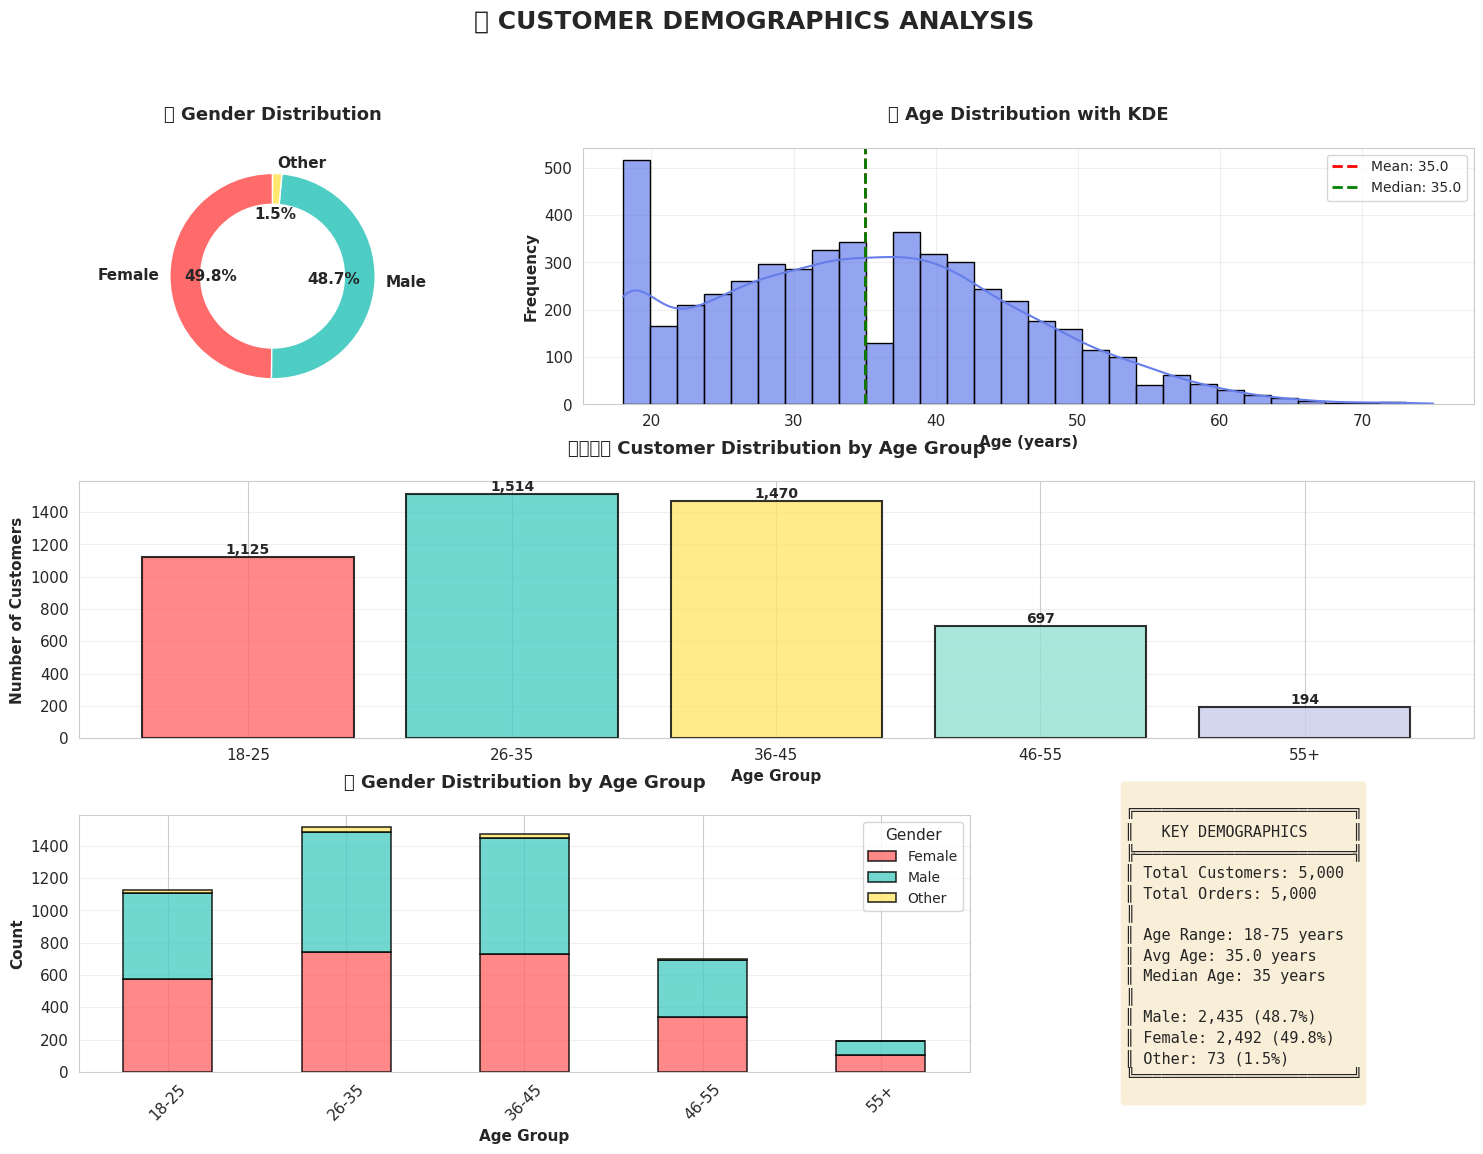

✅ Demographics dashboard generated!


In [10]:
# Create a stunning demographics dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Gender Distribution - Donut Chart
ax1 = fig.add_subplot(gs[0, 0])
gender_counts = df['Gender'].value_counts()
colors_gender = ['#FF6B6B', '#4ECDC4', '#FFE66D']
wedges, texts, autotexts = ax1.pie(gender_counts.values, labels=gender_counts.index,
                                     autopct='%1.1f%%', startangle=90, colors=colors_gender,
                                     textprops={'fontsize': 11, 'weight': 'bold'})
circle = plt.Circle((0, 0), 0.70, fc='white')
ax1.add_artist(circle)
ax1.set_title('👥 Gender Distribution', fontsize=13, weight='bold', pad=20)

# 2. Age Distribution - Histogram with KDE
ax2 = fig.add_subplot(gs[0, 1:])
sns.histplot(data=df, x='Age', bins=30, kde=True, color='#667eea', ax=ax2, edgecolor='black', alpha=0.7)
ax2.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Age"].mean():.1f}')
ax2.axvline(df['Age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Age"].median():.1f}')
ax2.set_title('📊 Age Distribution with KDE', fontsize=13, weight='bold', pad=20)
ax2.set_xlabel('Age (years)', fontsize=11, weight='bold')
ax2.set_ylabel('Frequency', fontsize=11, weight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# 3. Age Group Distribution - Bar Chart
ax3 = fig.add_subplot(gs[1, :])
age_group_counts = df['Age_Group'].value_counts().sort_index()
bars = ax3.bar(age_group_counts.index, age_group_counts.values,
               color=['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3', '#C7CEEA'],
               edgecolor='black', linewidth=1.5, alpha=0.8)
ax3.set_title('👨‍👩‍👧‍👦 Customer Distribution by Age Group', fontsize=13, weight='bold', pad=20)
ax3.set_xlabel('Age Group', fontsize=11, weight='bold')
ax3.set_ylabel('Number of Customers', fontsize=11, weight='bold')
ax3.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10, weight='bold')

# 4. Gender by Age Group - Stacked Bar
ax4 = fig.add_subplot(gs[2, :2])
gender_age = pd.crosstab(df['Age_Group'], df['Gender'])
gender_age.plot(kind='bar', stacked=True, ax=ax4, color=['#FF6B6B', '#4ECDC4', '#FFE66D'],
                edgecolor='black', linewidth=1.2, alpha=0.8)
ax4.set_title('👥 Gender Distribution by Age Group', fontsize=13, weight='bold', pad=20)
ax4.set_xlabel('Age Group', fontsize=11, weight='bold')
ax4.set_ylabel('Count', fontsize=11, weight='bold')
ax4.legend(title='Gender', fontsize=10, title_fontsize=11)
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

# 5. Key Stats Box
ax5 = fig.add_subplot(gs[2, 2])
ax5.axis('off')
stats_text = f"""
╔════════════════════════╗
║   KEY DEMOGRAPHICS     ║
╠════════════════════════╣
║ Total Customers: {df['Customer_ID'].nunique():,}
║ Total Orders: {len(df):,}
║
║ Age Range: {df['Age'].min()}-{df['Age'].max()} years
║ Avg Age: {df['Age'].mean():.1f} years
║ Median Age: {df['Age'].median():.0f} years
║
║ Male: {(df['Gender']=='Male').sum():,} ({(df['Gender']=='Male').sum()/len(df)*100:.1f}%)
║ Female: {(df['Gender']=='Female').sum():,} ({(df['Gender']=='Female').sum()/len(df)*100:.1f}%)
║ Other: {(df['Gender']=='Other').sum()} ({(df['Gender']=='Other').sum()/len(df)*100:.1f}%)
╚════════════════════════╝
"""
ax5.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('🎯 CUSTOMER DEMOGRAPHICS ANALYSIS', fontsize=18, weight='bold', y=0.995)
plt.show()

print("✅ Demographics dashboard generated!")

## 🗺️ Geographic Distribution
Where are our customers located?

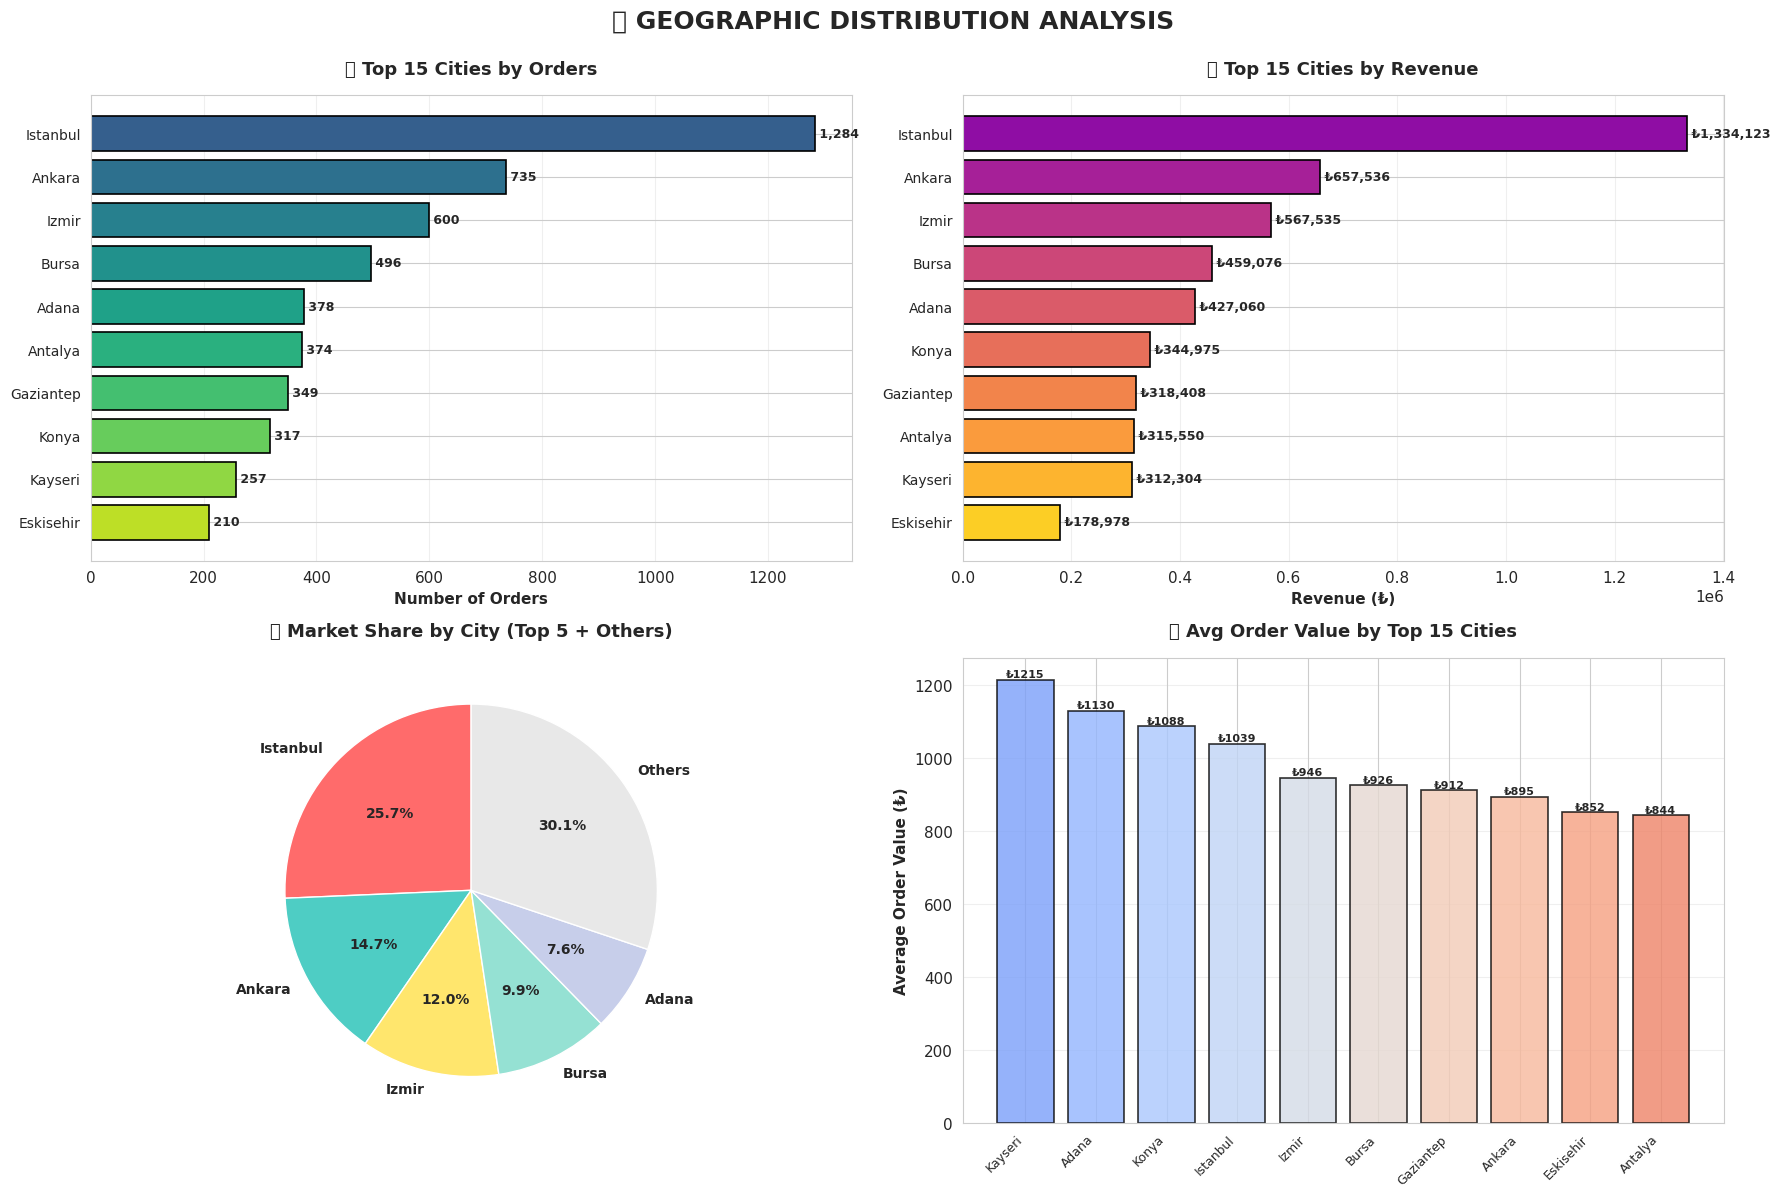


📍 Geographic Insights:
   • Total cities covered: 10
   • Top city: Istanbul (1,284 orders)
   • Top 3 cities represent: 52.4% of orders


In [11]:
# Geographic analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Top 15 Cities - Horizontal Bar
ax1 = axes[0, 0]
top_cities = df['City'].value_counts().head(15)
colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_cities)))
bars = ax1.barh(range(len(top_cities)), top_cities.values, color=colors_gradient, edgecolor='black', linewidth=1.2)
ax1.set_yticks(range(len(top_cities)))
ax1.set_yticklabels(top_cities.index, fontsize=10)
ax1.set_xlabel('Number of Orders', fontsize=11, weight='bold')
ax1.set_title('🏙️ Top 15 Cities by Orders', fontsize=13, weight='bold', pad=15)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_cities.values)):
    ax1.text(val, i, f' {val:,}', va='center', fontsize=9, weight='bold')

# 2. Revenue by Top Cities
ax2 = axes[0, 1]
city_revenue = df.groupby('City')['Final_Amount'].sum().sort_values(ascending=False).head(15)
bars2 = ax2.barh(range(len(city_revenue)), city_revenue.values,
                 color=plt.cm.plasma(np.linspace(0.3, 0.9, len(city_revenue))),
                 edgecolor='black', linewidth=1.2)
ax2.set_yticks(range(len(city_revenue)))
ax2.set_yticklabels(city_revenue.index, fontsize=10)
ax2.set_xlabel('Revenue (₺)', fontsize=11, weight='bold')
ax2.set_title('💰 Top 15 Cities by Revenue', fontsize=13, weight='bold', pad=15)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars2, city_revenue.values)):
    ax2.text(val, i, f' ₺{val:,.0f}', va='center', fontsize=9, weight='bold')

# 3. City Market Share - Pie Chart
ax3 = axes[1, 0]
top_5_cities = df['City'].value_counts().head(5)
other_cities = df['City'].value_counts()[5:].sum()
city_pie_data = pd.concat([top_5_cities, pd.Series({'Others': other_cities})])
colors_pie = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3', '#C7CEEA', '#E8E8E8']
wedges, texts, autotexts = ax3.pie(city_pie_data.values, labels=city_pie_data.index,
                                     autopct='%1.1f%%', startangle=90, colors=colors_pie,
                                     textprops={'fontsize': 10, 'weight': 'bold'})
ax3.set_title('🥧 Market Share by City (Top 5 + Others)', fontsize=13, weight='bold', pad=15)

# 4. Average Order Value by City
ax4 = axes[1, 1]
city_aov = df.groupby('City')['Final_Amount'].mean().sort_values(ascending=False).head(15)
bars4 = ax4.bar(range(len(city_aov)), city_aov.values,
                color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(city_aov))),
                edgecolor='black', linewidth=1.2, alpha=0.8)
ax4.set_xticks(range(len(city_aov)))
ax4.set_xticklabels(city_aov.index, rotation=45, ha='right', fontsize=9)
ax4.set_ylabel('Average Order Value (₺)', fontsize=11, weight='bold')
ax4.set_title('📊 Avg Order Value by Top 15 Cities', fontsize=13, weight='bold', pad=15)
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars4, city_aov.values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'₺{val:.0f}', ha='center', va='bottom', fontsize=8, weight='bold')

plt.suptitle('🗺️ GEOGRAPHIC DISTRIBUTION ANALYSIS', fontsize=18, weight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n📍 Geographic Insights:")
print(f"   • Total cities covered: {df['City'].nunique()}")
print(f"   • Top city: {top_cities.index[0]} ({top_cities.values[0]:,} orders)")
print(f"   • Top 3 cities represent: {top_cities.head(3).sum()/len(df)*100:.1f}% of orders")

## 🛍️ Product Category Performance
What are customers buying?

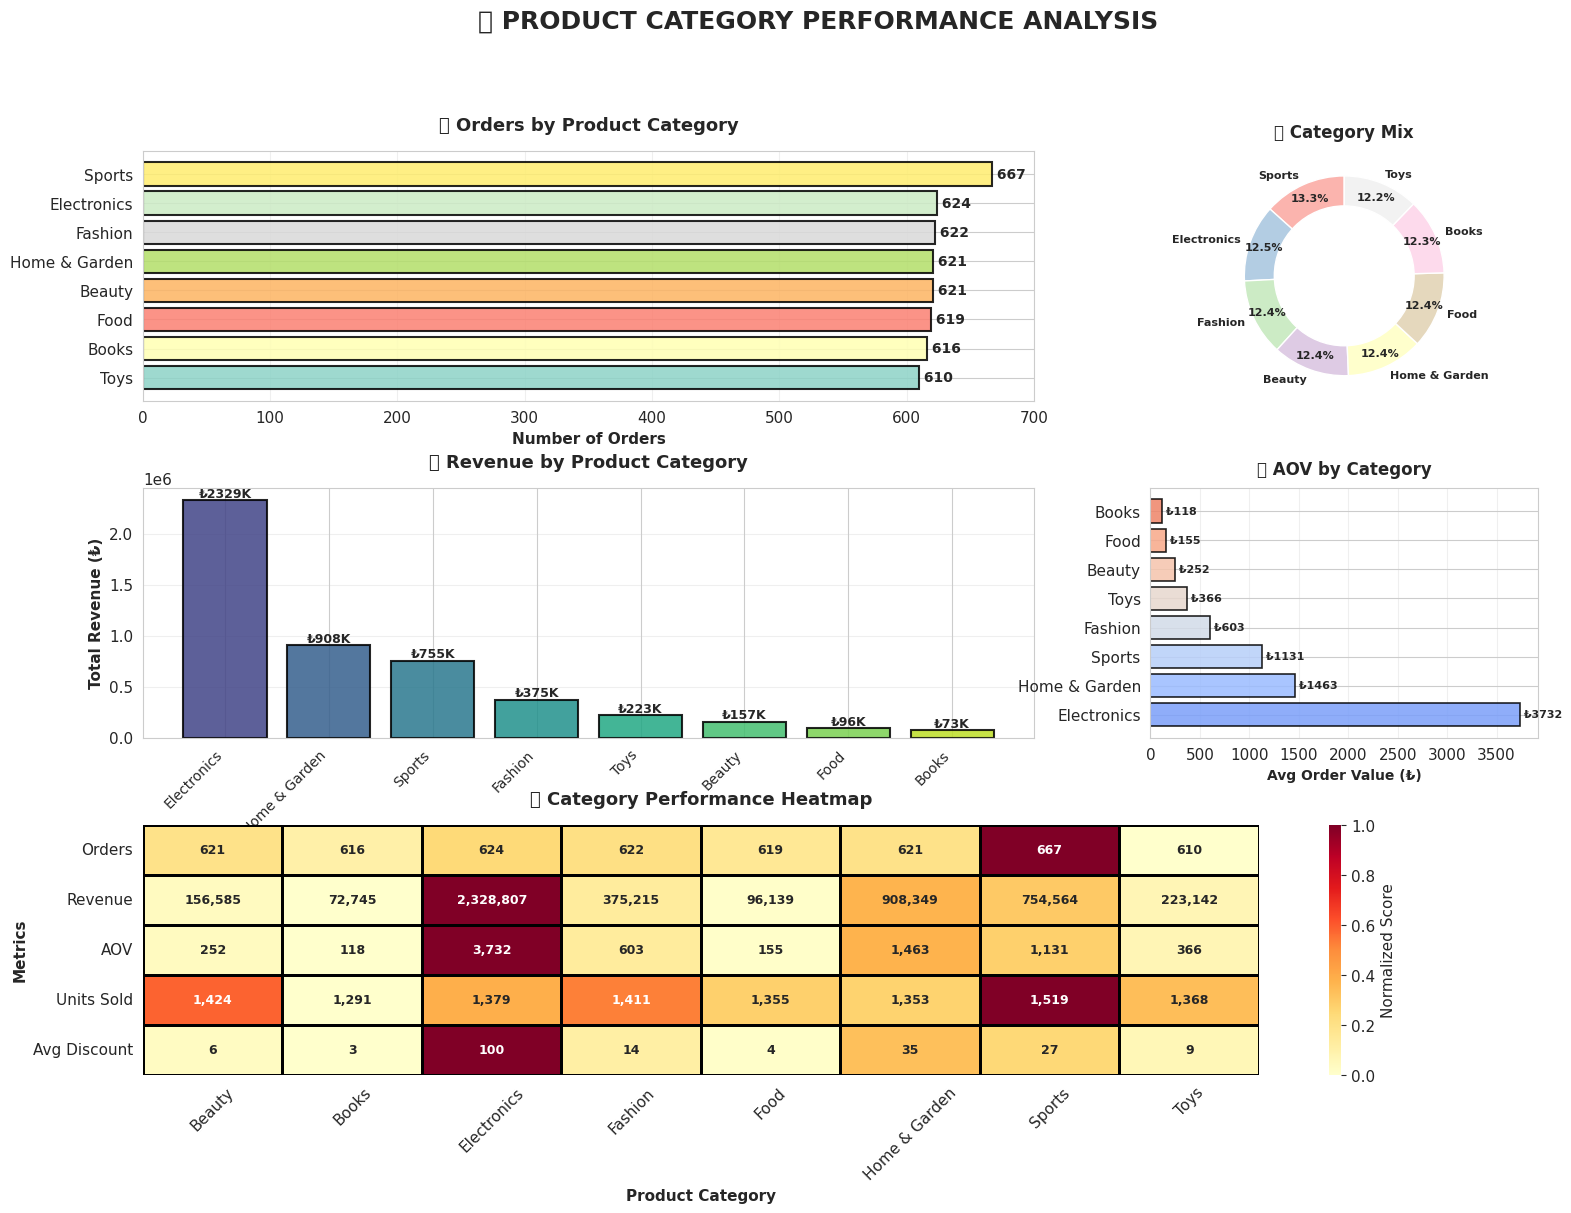


🏆 Category Champions:
   • Most orders: Sports (667 orders)
   • Highest revenue: Electronics (₺2,328,807)
   • Best AOV: Electronics (₺3732.06)


In [12]:
# Product category analysis
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Orders by Category
ax1 = fig.add_subplot(gs[0, :2])
category_orders = df['Product_Category'].value_counts().sort_values(ascending=True)
colors_cat = plt.cm.Set3(np.linspace(0, 1, len(category_orders)))
bars1 = ax1.barh(category_orders.index, category_orders.values, color=colors_cat,
                 edgecolor='black', linewidth=1.5, alpha=0.85)
ax1.set_xlabel('Number of Orders', fontsize=11, weight='bold')
ax1.set_title('📦 Orders by Product Category', fontsize=13, weight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars1, category_orders.values)):
    ax1.text(val, i, f' {val:,}', va='center', fontsize=10, weight='bold')

# 2. Category Distribution Donut
ax2 = fig.add_subplot(gs[0, 2])
category_dist = df['Product_Category'].value_counts()
colors_donut = plt.cm.Pastel1(np.linspace(0, 1, len(category_dist)))
wedges, texts, autotexts = ax2.pie(category_dist.values, labels=category_dist.index,
                                     autopct='%1.1f%%', startangle=90, colors=colors_donut,
                                     textprops={'fontsize': 8, 'weight': 'bold'},
                                     pctdistance=0.85)
circle = plt.Circle((0, 0), 0.70, fc='white')
ax2.add_artist(circle)
ax2.set_title('🥧 Category Mix', fontsize=12, weight='bold', pad=10)

# 3. Revenue by Category
ax3 = fig.add_subplot(gs[1, :2])
category_revenue = df.groupby('Product_Category')['Final_Amount'].sum().sort_values(ascending=False)
bars3 = ax3.bar(range(len(category_revenue)), category_revenue.values,
                color=plt.cm.viridis(np.linspace(0.2, 0.9, len(category_revenue))),
                edgecolor='black', linewidth=1.5, alpha=0.85)
ax3.set_xticks(range(len(category_revenue)))
ax3.set_xticklabels(category_revenue.index, rotation=45, ha='right', fontsize=10)
ax3.set_ylabel('Total Revenue (₺)', fontsize=11, weight='bold')
ax3.set_title('💰 Revenue by Product Category', fontsize=13, weight='bold', pad=15)
ax3.grid(axis='y', alpha=0.3)

for bar, val in zip(bars3, category_revenue.values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'₺{val/1000:.0f}K', ha='center', va='bottom', fontsize=9, weight='bold')

# 4. Average Order Value by Category
ax4 = fig.add_subplot(gs[1, 2])
category_aov = df.groupby('Product_Category')['Final_Amount'].mean().sort_values(ascending=False)
bars4 = ax4.barh(category_aov.index, category_aov.values,
                 color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(category_aov))),
                 edgecolor='black', linewidth=1.2, alpha=0.85)
ax4.set_xlabel('Avg Order Value (₺)', fontsize=10, weight='bold')
ax4.set_title('📊 AOV by Category', fontsize=12, weight='bold', pad=10)
ax4.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars4, category_aov.values)):
    ax4.text(val, i, f' ₺{val:.0f}', va='center', fontsize=8, weight='bold')

# 5. Category Performance Heatmap
ax5 = fig.add_subplot(gs[2, :])
category_metrics = df.groupby('Product_Category').agg({
    'Order_ID': 'count',
    'Final_Amount': ['sum', 'mean'],
    'Quantity': 'sum',
    'Discount_Amount': 'mean'
}).round(0)
category_metrics.columns = ['Orders', 'Revenue', 'AOV', 'Units Sold', 'Avg Discount']
category_metrics_normalized = (category_metrics - category_metrics.min()) / (category_metrics.max() - category_metrics.min())

sns.heatmap(category_metrics_normalized.T, annot=category_metrics.T, fmt=',.0f',
            cmap='YlOrRd', linewidths=1, linecolor='black', cbar_kws={'label': 'Normalized Score'},
            ax=ax5, annot_kws={'fontsize': 9, 'weight': 'bold'})
ax5.set_title('🔥 Category Performance Heatmap', fontsize=13, weight='bold', pad=15)
ax5.set_xlabel('Product Category', fontsize=11, weight='bold')
ax5.set_ylabel('Metrics', fontsize=11, weight='bold')
ax5.tick_params(axis='x', rotation=45)

plt.suptitle('🛍️ PRODUCT CATEGORY PERFORMANCE ANALYSIS', fontsize=18, weight='bold', y=0.998)
plt.show()

print("\n🏆 Category Champions:")
print(f"   • Most orders: {category_orders.index[-1]} ({category_orders.values[-1]:,} orders)")
print(f"   • Highest revenue: {category_revenue.index[0]} (₺{category_revenue.values[0]:,.0f})")
print(f"   • Best AOV: {category_aov.index[0]} (₺{category_aov.values[0]:.2f})")

## 📈 Revenue & Sales Trends Over Time
How is the business performing?

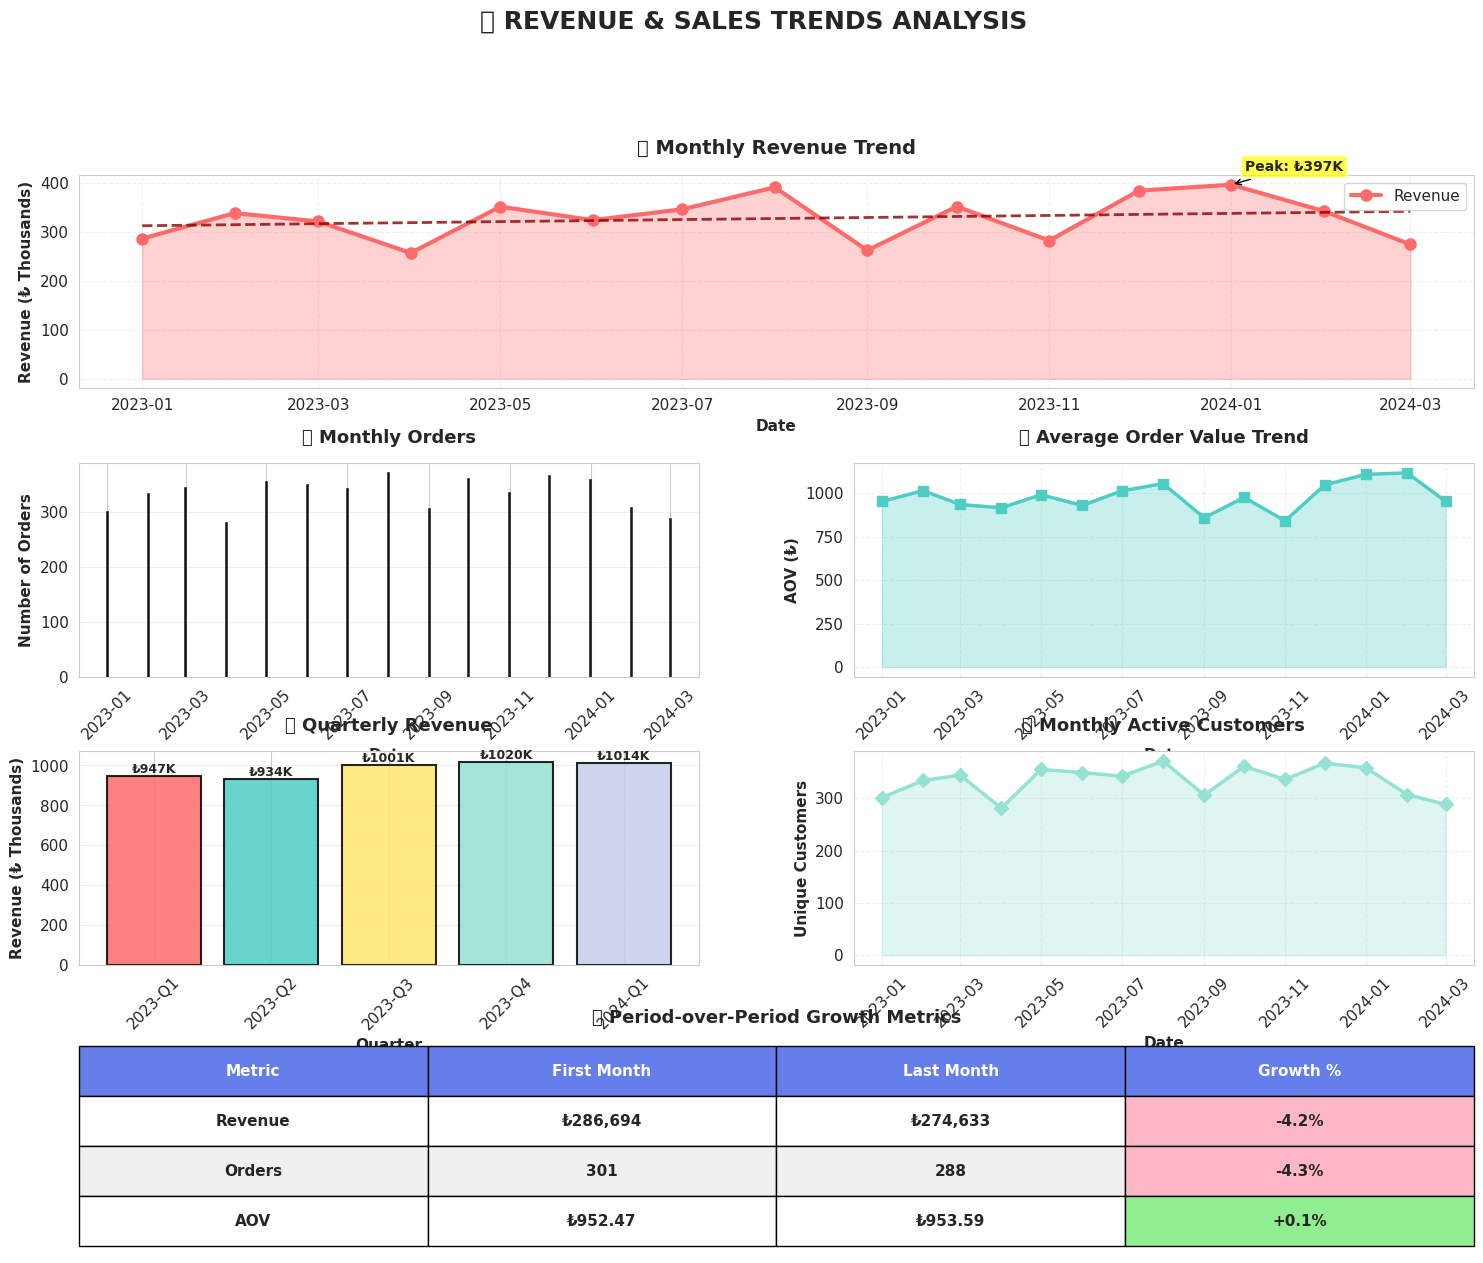

✅ Time series analysis complete!


In [13]:
# Time series analysis
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.25)

# Prepare monthly data
monthly_data = df.groupby(df['Date'].dt.to_period('M')).agg({
    'Final_Amount': 'sum',
    'Order_ID': 'count',
    'Customer_ID': 'nunique',
    'Discount_Amount': 'sum'
}).reset_index()
monthly_data['Date'] = monthly_data['Date'].dt.to_timestamp()
monthly_data['AOV'] = monthly_data['Final_Amount'] / monthly_data['Order_ID']

# 1. Monthly Revenue Trend
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(monthly_data['Date'], monthly_data['Final_Amount']/1000,
         marker='o', linewidth=3, markersize=8, color='#FF6B6B', label='Revenue')
ax1.fill_between(monthly_data['Date'], monthly_data['Final_Amount']/1000,
                  alpha=0.3, color='#FF6B6B')
ax1.set_title('💰 Monthly Revenue Trend', fontsize=14, weight='bold', pad=15)
ax1.set_xlabel('Date', fontsize=11, weight='bold')
ax1.set_ylabel('Revenue (₺ Thousands)', fontsize=11, weight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=11)

# Add trend line
z = np.polyfit(range(len(monthly_data)), monthly_data['Final_Amount']/1000, 1)
p = np.poly1d(z)
ax1.plot(monthly_data['Date'], p(range(len(monthly_data))),
         "--", color='darkred', linewidth=2, alpha=0.8, label='Trend')

# Annotate max and min
max_idx = monthly_data['Final_Amount'].idxmax()
min_idx = monthly_data['Final_Amount'].idxmin()
ax1.annotate(f"Peak: ₺{monthly_data.loc[max_idx, 'Final_Amount']/1000:.0f}K",
             xy=(monthly_data.loc[max_idx, 'Date'], monthly_data.loc[max_idx, 'Final_Amount']/1000),
             xytext=(10, 10), textcoords='offset points', fontsize=10, weight='bold',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', color='black'))

# 2. Monthly Orders Trend
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(monthly_data['Date'], monthly_data['Order_ID'],
        color=plt.cm.viridis(np.linspace(0.3, 0.9, len(monthly_data))),
        edgecolor='black', linewidth=1.2, alpha=0.85)
ax2.set_title('📦 Monthly Orders', fontsize=13, weight='bold', pad=15)
ax2.set_xlabel('Date', fontsize=11, weight='bold')
ax2.set_ylabel('Number of Orders', fontsize=11, weight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Average Order Value Trend
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(monthly_data['Date'], monthly_data['AOV'],
         marker='s', linewidth=2.5, markersize=7, color='#4ECDC4')
ax3.fill_between(monthly_data['Date'], monthly_data['AOV'], alpha=0.3, color='#4ECDC4')
ax3.set_title('💵 Average Order Value Trend', fontsize=13, weight='bold', pad=15)
ax3.set_xlabel('Date', fontsize=11, weight='bold')
ax3.set_ylabel('AOV (₺)', fontsize=11, weight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.tick_params(axis='x', rotation=45)

# 4. Quarterly Comparison
ax4 = fig.add_subplot(gs[2, 0])
quarterly_data = df.groupby(['Year', 'Quarter'])['Final_Amount'].sum().reset_index()
quarterly_data['Period'] = quarterly_data['Year'].astype(str) + '-Q' + quarterly_data['Quarter'].astype(str)
bars = ax4.bar(quarterly_data['Period'], quarterly_data['Final_Amount']/1000,
               color=['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3', '#C7CEEA'],
               edgecolor='black', linewidth=1.5, alpha=0.85)
ax4.set_title('📊 Quarterly Revenue', fontsize=13, weight='bold', pad=15)
ax4.set_xlabel('Quarter', fontsize=11, weight='bold')
ax4.set_ylabel('Revenue (₺ Thousands)', fontsize=11, weight='bold')
ax4.grid(axis='y', alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, quarterly_data['Final_Amount']/1000):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'₺{val:.0f}K', ha='center', va='bottom', fontsize=9, weight='bold')

# 5. Monthly Customer Growth
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(monthly_data['Date'], monthly_data['Customer_ID'],
         marker='D', linewidth=2.5, markersize=7, color='#95E1D3')
ax5.fill_between(monthly_data['Date'], monthly_data['Customer_ID'], alpha=0.3, color='#95E1D3')
ax5.set_title('👥 Monthly Active Customers', fontsize=13, weight='bold', pad=15)
ax5.set_xlabel('Date', fontsize=11, weight='bold')
ax5.set_ylabel('Unique Customers', fontsize=11, weight='bold')
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.tick_params(axis='x', rotation=45)

# 6. Growth Metrics Table
ax6 = fig.add_subplot(gs[3, :])
ax6.axis('off')

# Calculate growth metrics
first_month_revenue = monthly_data['Final_Amount'].iloc[0]
last_month_revenue = monthly_data['Final_Amount'].iloc[-1]
revenue_growth = ((last_month_revenue - first_month_revenue) / first_month_revenue * 100)

first_month_orders = monthly_data['Order_ID'].iloc[0]
last_month_orders = monthly_data['Order_ID'].iloc[-1]
order_growth = ((last_month_orders - first_month_orders) / first_month_orders * 100)

metrics_data = [
    ['Metric', 'First Month', 'Last Month', 'Growth %'],
    ['Revenue', f'₺{first_month_revenue:,.0f}', f'₺{last_month_revenue:,.0f}', f'{revenue_growth:+.1f}%'],
    ['Orders', f'{first_month_orders:,}', f'{last_month_orders:,}', f'{order_growth:+.1f}%'],
    ['AOV', f'₺{monthly_data["AOV"].iloc[0]:.2f}', f'₺{monthly_data["AOV"].iloc[-1]:.2f}',
     f'{((monthly_data["AOV"].iloc[-1] - monthly_data["AOV"].iloc[0]) / monthly_data["AOV"].iloc[0] * 100):+.1f}%'],
]

table = ax6.table(cellText=metrics_data, cellLoc='center', loc='center',
                  colWidths=[0.25, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 3)

# Style header row
for i in range(4):
    cell = table[(0, i)]
    cell.set_facecolor('#667eea')
    cell.set_text_props(weight='bold', color='white')

# Style data rows
for i in range(1, 4):
    for j in range(4):
        cell = table[(i, j)]
        if j == 3:  # Growth column
            value = float(metrics_data[i][3].replace('%', '').replace('+', ''))
            if value > 0:
                cell.set_facecolor('#90EE90')
            elif value < 0:
                cell.set_facecolor('#FFB6C6')
            else:
                cell.set_facecolor('#FFFACD')
        else:
            cell.set_facecolor('#F0F0F0' if i % 2 == 0 else 'white')
        cell.set_text_props(weight='bold')

ax6.set_title('📊 Period-over-Period Growth Metrics', fontsize=13, weight='bold', pad=20, y=0.95)

plt.suptitle('📈 REVENUE & SALES TRENDS ANALYSIS', fontsize=18, weight='bold', y=0.998)
plt.show()

print("✅ Time series analysis complete!")

## 🎁 Discount Strategy Analysis
How effective are our discounts?

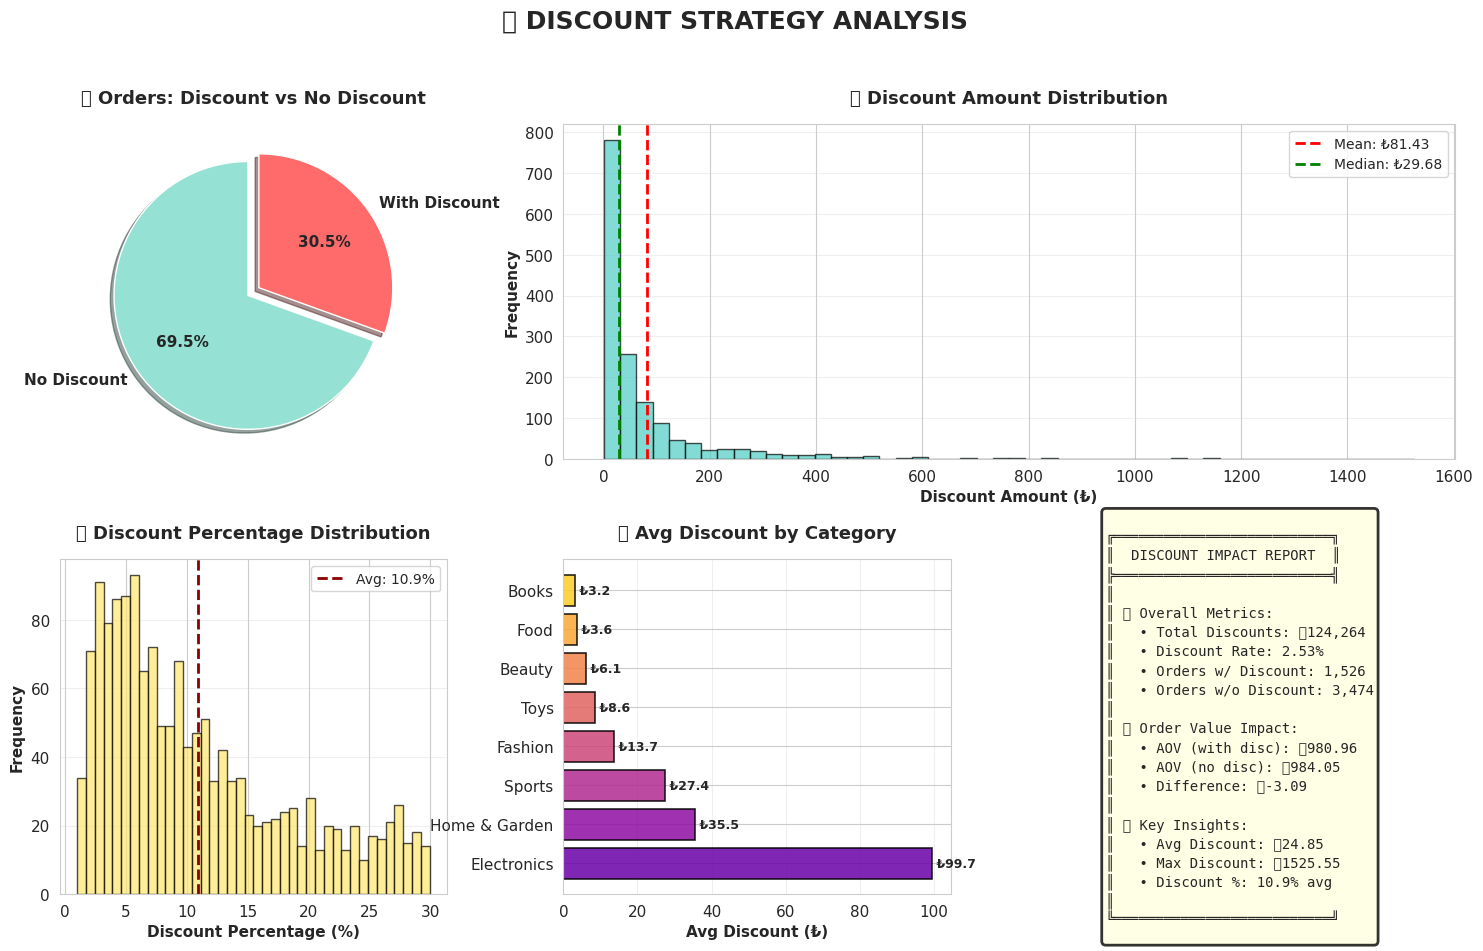

✅ Discount analysis complete!


In [14]:
# Discount analysis
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Discount vs No Discount
ax1 = fig.add_subplot(gs[0, 0])
discount_split = df['Has_Discount'].value_counts()
colors_discount = ['#95E1D3', '#FF6B6B']
explode = (0.05, 0.05)
wedges, texts, autotexts = ax1.pie(discount_split.values, labels=['No Discount', 'With Discount'],
                                     autopct='%1.1f%%', startangle=90, colors=colors_discount,
                                     explode=explode, textprops={'fontsize': 11, 'weight': 'bold'},
                                     shadow=True)
ax1.set_title('🎁 Orders: Discount vs No Discount', fontsize=13, weight='bold', pad=15)

# 2. Discount Amount Distribution
ax2 = fig.add_subplot(gs[0, 1:])
discount_data = df[df['Discount_Amount'] > 0]['Discount_Amount']
ax2.hist(discount_data, bins=50, color='#4ECDC4', edgecolor='black', alpha=0.7)
ax2.axvline(discount_data.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: ₺{discount_data.mean():.2f}')
ax2.axvline(discount_data.median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: ₺{discount_data.median():.2f}')
ax2.set_title('💰 Discount Amount Distribution', fontsize=13, weight='bold', pad=15)
ax2.set_xlabel('Discount Amount (₺)', fontsize=11, weight='bold')
ax2.set_ylabel('Frequency', fontsize=11, weight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# 3. Discount Percentage Distribution
ax3 = fig.add_subplot(gs[1, 0])
discount_pct_data = df[df['Discount_Percentage'] > 0]['Discount_Percentage']
ax3.hist(discount_pct_data, bins=40, color='#FFE66D', edgecolor='black', alpha=0.7)
ax3.axvline(discount_pct_data.mean(), color='darkred', linestyle='--', linewidth=2,
            label=f'Avg: {discount_pct_data.mean():.1f}%')
ax3.set_title('📊 Discount Percentage Distribution', fontsize=13, weight='bold', pad=15)
ax3.set_xlabel('Discount Percentage (%)', fontsize=11, weight='bold')
ax3.set_ylabel('Frequency', fontsize=11, weight='bold')
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3)

# 4. Discount by Category
ax4 = fig.add_subplot(gs[1, 1])
category_discount = df.groupby('Product_Category').agg({
    'Discount_Amount': 'mean',
    'Has_Discount': 'mean'
}).sort_values('Discount_Amount', ascending=False)

bars = ax4.barh(category_discount.index, category_discount['Discount_Amount'],
                color=plt.cm.plasma(np.linspace(0.2, 0.9, len(category_discount))),
                edgecolor='black', linewidth=1.2, alpha=0.85)
ax4.set_xlabel('Avg Discount (₺)', fontsize=11, weight='bold')
ax4.set_title('🏷️ Avg Discount by Category', fontsize=13, weight='bold', pad=15)
ax4.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, category_discount['Discount_Amount'])):
    ax4.text(val, i, f' ₺{val:.1f}', va='center', fontsize=9, weight='bold')

# 5. Impact Analysis
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')

# Calculate metrics
orders_with_discount = df[df['Has_Discount'] == 1]
orders_without_discount = df[df['Has_Discount'] == 0]

avg_order_with_discount = orders_with_discount['Final_Amount'].mean()
avg_order_without_discount = orders_without_discount['Final_Amount'].mean()

total_revenue = df['Final_Amount'].sum()
total_discounts = df['Discount_Amount'].sum()
discount_rate = (total_discounts / total_revenue * 100)

impact_text = f"""
╔══════════════════════════╗
║  DISCOUNT IMPACT REPORT  ║
╠══════════════════════════╣
║
║ 📊 Overall Metrics:
║   • Total Discounts: ₺{total_discounts:,.0f}
║   • Discount Rate: {discount_rate:.2f}%
║   • Orders w/ Discount: {len(orders_with_discount):,}
║   • Orders w/o Discount: {len(orders_without_discount):,}
║
║ 💰 Order Value Impact:
║   • AOV (with disc): ₺{avg_order_with_discount:.2f}
║   • AOV (no disc): ₺{avg_order_without_discount:.2f}
║   • Difference: ₺{avg_order_with_discount - avg_order_without_discount:.2f}
║
║ 🎯 Key Insights:
║   • Avg Discount: ₺{df['Discount_Amount'].mean():.2f}
║   • Max Discount: ₺{df['Discount_Amount'].max():.2f}
║   • Discount %: {discount_pct_data.mean():.1f}% avg
║
╚══════════════════════════╝
"""

ax5.text(0.1, 0.5, impact_text, fontsize=10, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, edgecolor='black', linewidth=2))

plt.suptitle('🎁 DISCOUNT STRATEGY ANALYSIS', fontsize=18, weight='bold', y=0.995)
plt.show()

print("✅ Discount analysis complete!")

## 💳 Customer Spending Behavior
Deep dive into purchase patterns

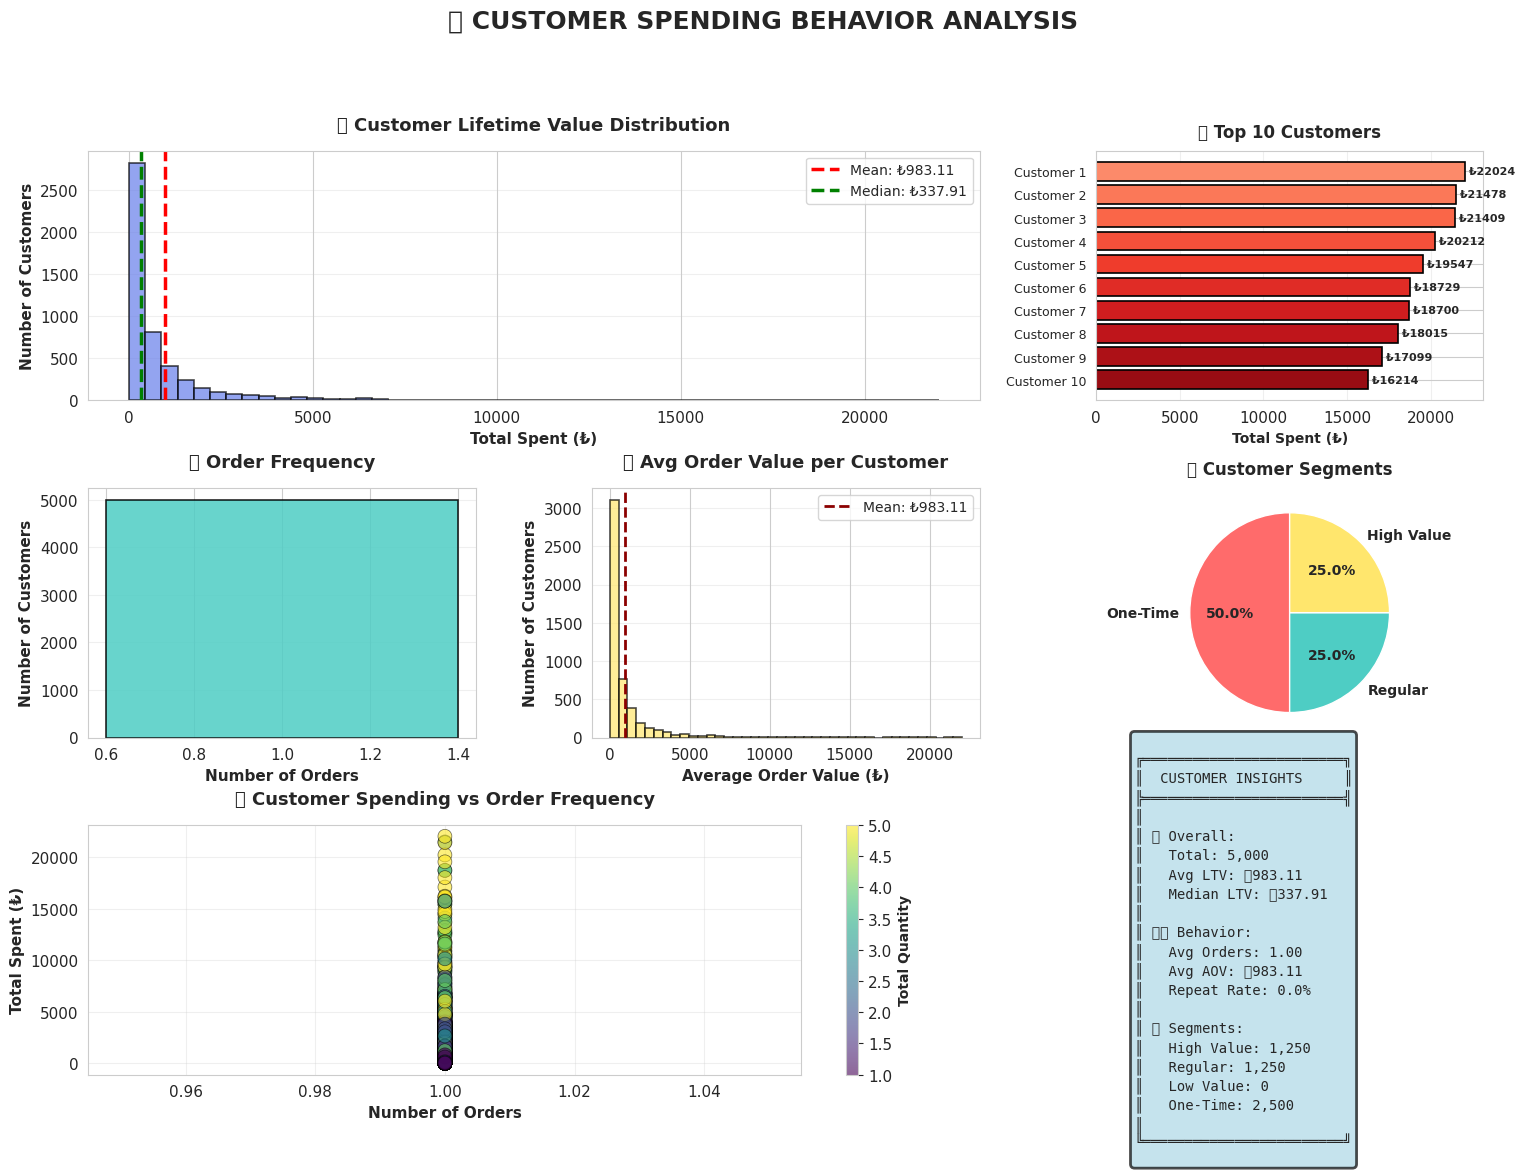

✅ Customer behavior analysis complete!


In [15]:
# Customer behavior analysis
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Aggregate customer data
customer_behavior = df.groupby('Customer_ID').agg({
    'Final_Amount': ['sum', 'mean', 'count'],
    'Quantity': 'sum',
    'Discount_Amount': 'sum',
    'Product_Category': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
}).reset_index()
customer_behavior.columns = ['Customer_ID', 'Total_Spent', 'Avg_Order', 'Order_Count',
                              'Total_Quantity', 'Total_Discount', 'Favorite_Category']

# 1. Customer Lifetime Value Distribution
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(customer_behavior['Total_Spent'], bins=50, color='#667eea',
         edgecolor='black', alpha=0.7, linewidth=1.2)
ax1.axvline(customer_behavior['Total_Spent'].mean(), color='red', linestyle='--',
            linewidth=2.5, label=f"Mean: ₺{customer_behavior['Total_Spent'].mean():.2f}")
ax1.axvline(customer_behavior['Total_Spent'].median(), color='green', linestyle='--',
            linewidth=2.5, label=f"Median: ₺{customer_behavior['Total_Spent'].median():.2f}")
ax1.set_title('💰 Customer Lifetime Value Distribution', fontsize=13, weight='bold', pad=15)
ax1.set_xlabel('Total Spent (₺)', fontsize=11, weight='bold')
ax1.set_ylabel('Number of Customers', fontsize=11, weight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# 2. Top 10 Spenders
ax2 = fig.add_subplot(gs[0, 2])
top_spenders = customer_behavior.nlargest(10, 'Total_Spent')
bars = ax2.barh(range(len(top_spenders)), top_spenders['Total_Spent'],
                color=plt.cm.Reds(np.linspace(0.4, 0.9, len(top_spenders))),
                edgecolor='black', linewidth=1.2)
ax2.set_yticks(range(len(top_spenders)))
ax2.set_yticklabels([f"Customer {i+1}" for i in range(len(top_spenders))], fontsize=9)
ax2.set_xlabel('Total Spent (₺)', fontsize=10, weight='bold')
ax2.set_title('🏆 Top 10 Customers', fontsize=12, weight='bold', pad=10)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, top_spenders['Total_Spent'])):
    ax2.text(val, i, f' ₺{val:.0f}', va='center', fontsize=8, weight='bold')

# 3. Order Frequency Distribution
ax3 = fig.add_subplot(gs[1, 0])
order_freq = customer_behavior['Order_Count'].value_counts().sort_index()
ax3.bar(order_freq.index, order_freq.values, color='#4ECDC4',
        edgecolor='black', linewidth=1.2, alpha=0.85)
ax3.set_title('📦 Order Frequency', fontsize=13, weight='bold', pad=15)
ax3.set_xlabel('Number of Orders', fontsize=11, weight='bold')
ax3.set_ylabel('Number of Customers', fontsize=11, weight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Average Order Value Distribution
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(customer_behavior['Avg_Order'], bins=40, color='#FFE66D',
         edgecolor='black', alpha=0.7, linewidth=1.2)
ax4.axvline(customer_behavior['Avg_Order'].mean(), color='darkred', linestyle='--',
            linewidth=2, label=f"Mean: ₺{customer_behavior['Avg_Order'].mean():.2f}")
ax4.set_title('💵 Avg Order Value per Customer', fontsize=13, weight='bold', pad=15)
ax4.set_xlabel('Average Order Value (₺)', fontsize=11, weight='bold')
ax4.set_ylabel('Number of Customers', fontsize=11, weight='bold')
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

# 5. Customer Segmentation (RFM-like)
ax5 = fig.add_subplot(gs[1, 2])
# Segment customers
customer_behavior['Segment'] = 'Regular'
customer_behavior.loc[customer_behavior['Total_Spent'] > customer_behavior['Total_Spent'].quantile(0.75), 'Segment'] = 'High Value'
customer_behavior.loc[customer_behavior['Total_Spent'] < customer_behavior['Total_Spent'].quantile(0.25), 'Segment'] = 'Low Value'
customer_behavior.loc[(customer_behavior['Order_Count'] == 1) &
                      (customer_behavior['Total_Spent'] < customer_behavior['Total_Spent'].median()), 'Segment'] = 'One-Time'

segment_counts = customer_behavior['Segment'].value_counts()
colors_seg = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3']
wedges, texts, autotexts = ax5.pie(segment_counts.values, labels=segment_counts.index,
                                     autopct='%1.1f%%', startangle=90, colors=colors_seg,
                                     textprops={'fontsize': 10, 'weight': 'bold'})
ax5.set_title('👥 Customer Segments', fontsize=12, weight='bold', pad=10)

# 6. Spending vs Order Count
ax6 = fig.add_subplot(gs[2, :2])
scatter = ax6.scatter(customer_behavior['Order_Count'], customer_behavior['Total_Spent'],
                      c=customer_behavior['Total_Quantity'], cmap='viridis',
                      s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
ax6.set_title('🎯 Customer Spending vs Order Frequency', fontsize=13, weight='bold', pad=15)
ax6.set_xlabel('Number of Orders', fontsize=11, weight='bold')
ax6.set_ylabel('Total Spent (₺)', fontsize=11, weight='bold')
ax6.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax6)
cbar.set_label('Total Quantity', fontsize=10, weight='bold')

# 7. Customer Stats Box
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')

stats_text = f"""
╔════════════════════════╗
║  CUSTOMER INSIGHTS     ║
╠════════════════════════╣
║
║ 📊 Overall:
║   Total: {len(customer_behavior):,}
║   Avg LTV: ₺{customer_behavior['Total_Spent'].mean():.2f}
║   Median LTV: ₺{customer_behavior['Total_Spent'].median():.2f}
║
║ 🛍️ Behavior:
║   Avg Orders: {customer_behavior['Order_Count'].mean():.2f}
║   Avg AOV: ₺{customer_behavior['Avg_Order'].mean():.2f}
║   Repeat Rate: {(customer_behavior['Order_Count'] > 1).mean()*100:.1f}%
║
║ 🏆 Segments:
║   High Value: {segment_counts.get('High Value', 0):,}
║   Regular: {segment_counts.get('Regular', 0):,}
║   Low Value: {segment_counts.get('Low Value', 0):,}
║   One-Time: {segment_counts.get('One-Time', 0):,}
║
╚════════════════════════╝
"""

ax7.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7,
                  edgecolor='black', linewidth=2))

plt.suptitle('💳 CUSTOMER SPENDING BEHAVIOR ANALYSIS', fontsize=18, weight='bold', y=0.998)
plt.show()

print("✅ Customer behavior analysis complete!")

## 👥 Gender & Age Demographics Deep Dive
Understanding customer preferences by demographics

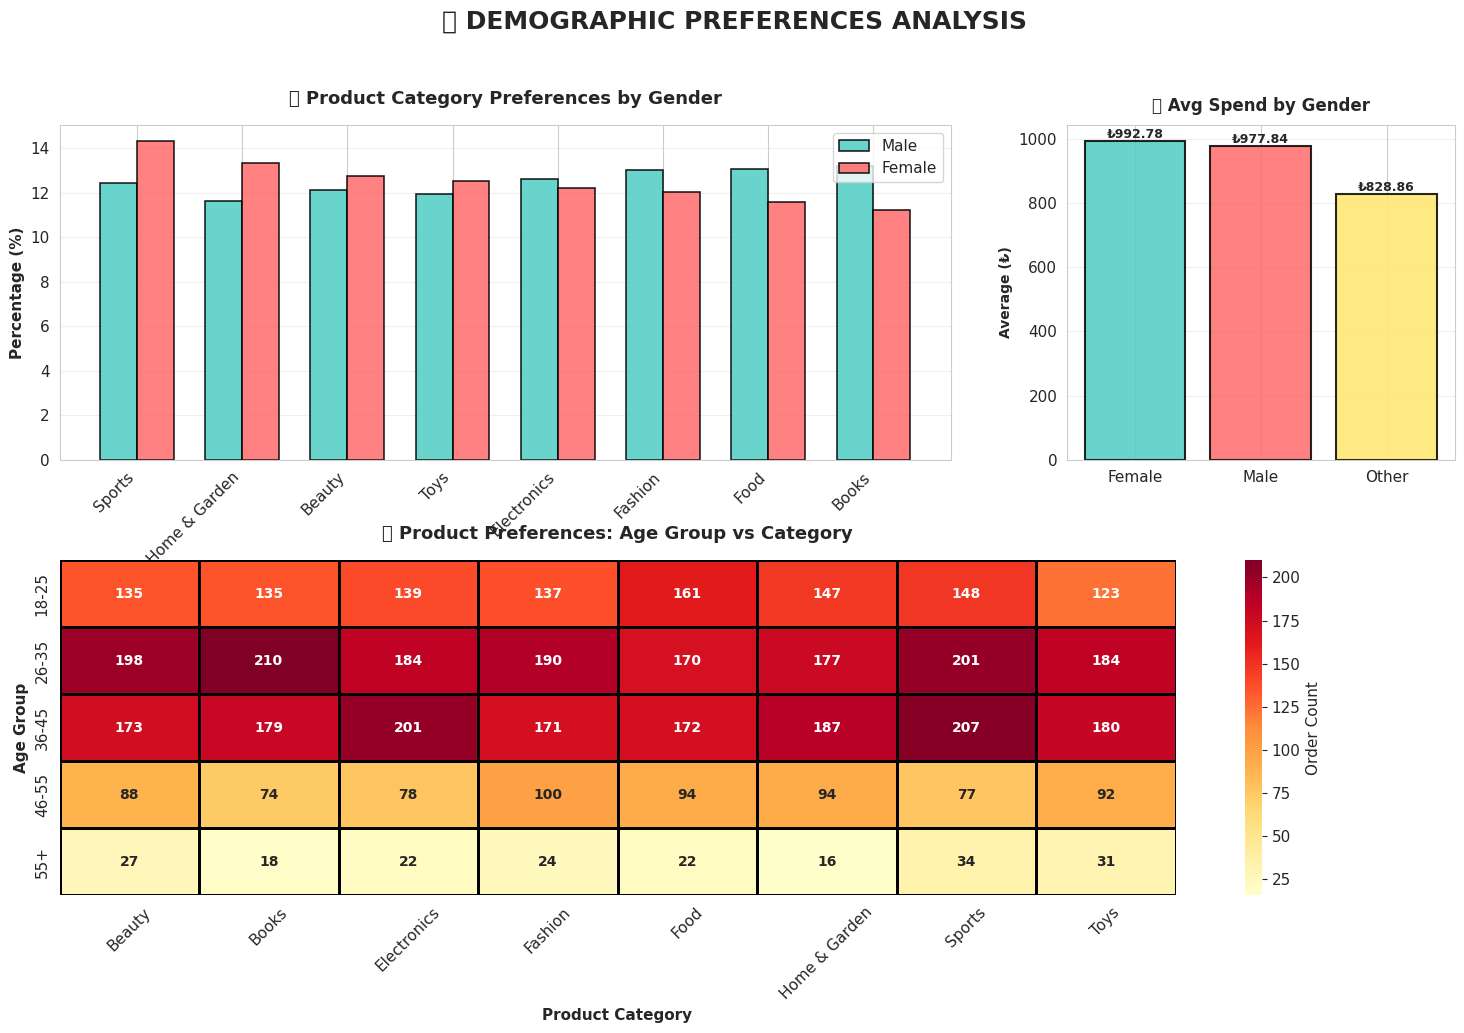


🎯 Key Demographic Insights:

Top Category by Gender:
   • Male: Books
   • Female: Sports

Top Category by Age Group:
   • 18-25: Food (161 orders)
   • 26-35: Books (210 orders)
   • 36-45: Sports (207 orders)
   • 46-55: Fashion (100 orders)
   • 55+: Sports (34 orders)


In [16]:
# Gender and age analysis
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Category Preferences by Gender
ax1 = fig.add_subplot(gs[0, :2])
gender_category = pd.crosstab(df['Product_Category'], df['Gender'], normalize='columns') * 100
gender_category_plot = gender_category[['Male', 'Female']].sort_values('Female', ascending=False)

x = np.arange(len(gender_category_plot))
width = 0.35

bars1 = ax1.bar(x - width/2, gender_category_plot['Male'], width, label='Male',
                color='#4ECDC4', edgecolor='black', linewidth=1.2, alpha=0.85)
bars2 = ax1.bar(x + width/2, gender_category_plot['Female'], width, label='Female',
                color='#FF6B6B', edgecolor='black', linewidth=1.2, alpha=0.85)

ax1.set_title('🎯 Product Category Preferences by Gender', fontsize=13, weight='bold', pad=15)
ax1.set_xlabel('Product Category', fontsize=11, weight='bold')
ax1.set_ylabel('Percentage (%)', fontsize=11, weight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(gender_category_plot.index, rotation=45, ha='right')
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# 2. Spending by Gender
ax2 = fig.add_subplot(gs[0, 2])
gender_spending = df.groupby('Gender').agg({
    'Final_Amount': ['sum', 'mean'],
    'Order_ID': 'count'
})
gender_spending.columns = ['Total', 'Average', 'Orders']

colors_gender = ['#4ECDC4', '#FF6B6B', '#FFE66D']
bars = ax2.bar(gender_spending.index, gender_spending['Average'],
               color=colors_gender, edgecolor='black', linewidth=1.5, alpha=0.85)
ax2.set_title('💰 Avg Spend by Gender', fontsize=12, weight='bold', pad=10)
ax2.set_ylabel('Average (₺)', fontsize=10, weight='bold')
ax2.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, gender_spending['Average']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'₺{val:.2f}', ha='center', va='bottom', fontsize=9, weight='bold')

# 3. Age Group vs Category Heatmap
ax3 = fig.add_subplot(gs[1, :])
age_category = pd.crosstab(df['Age_Group'], df['Product_Category'])
sns.heatmap(age_category, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=1, linecolor='black', cbar_kws={'label': 'Order Count'},
            ax=ax3, annot_kws={'fontsize': 10, 'weight': 'bold'})
ax3.set_title('🔥 Product Preferences: Age Group vs Category', fontsize=13, weight='bold', pad=15)
ax3.set_xlabel('Product Category', fontsize=11, weight='bold')
ax3.set_ylabel('Age Group', fontsize=11, weight='bold')
ax3.tick_params(axis='x', rotation=45)

plt.suptitle('👥 DEMOGRAPHIC PREFERENCES ANALYSIS', fontsize=18, weight='bold', y=0.995)
plt.show()

# Additional insights
print("\n🎯 Key Demographic Insights:")
print("\nTop Category by Gender:")
for gender in ['Male', 'Female']:
    top_cat = df[df['Gender'] == gender]['Product_Category'].value_counts().index[0]
    print(f"   • {gender}: {top_cat}")

print("\nTop Category by Age Group:")
for age_group in df['Age_Group'].cat.categories:
    top_cat = df[df['Age_Group'] == age_group]['Product_Category'].value_counts().index[0]
    count = df[df['Age_Group'] == age_group]['Product_Category'].value_counts().values[0]
    print(f"   • {age_group}: {top_cat} ({count} orders)")

## ⏰ Temporal Patterns & Shopping Behavior
When do customers shop?

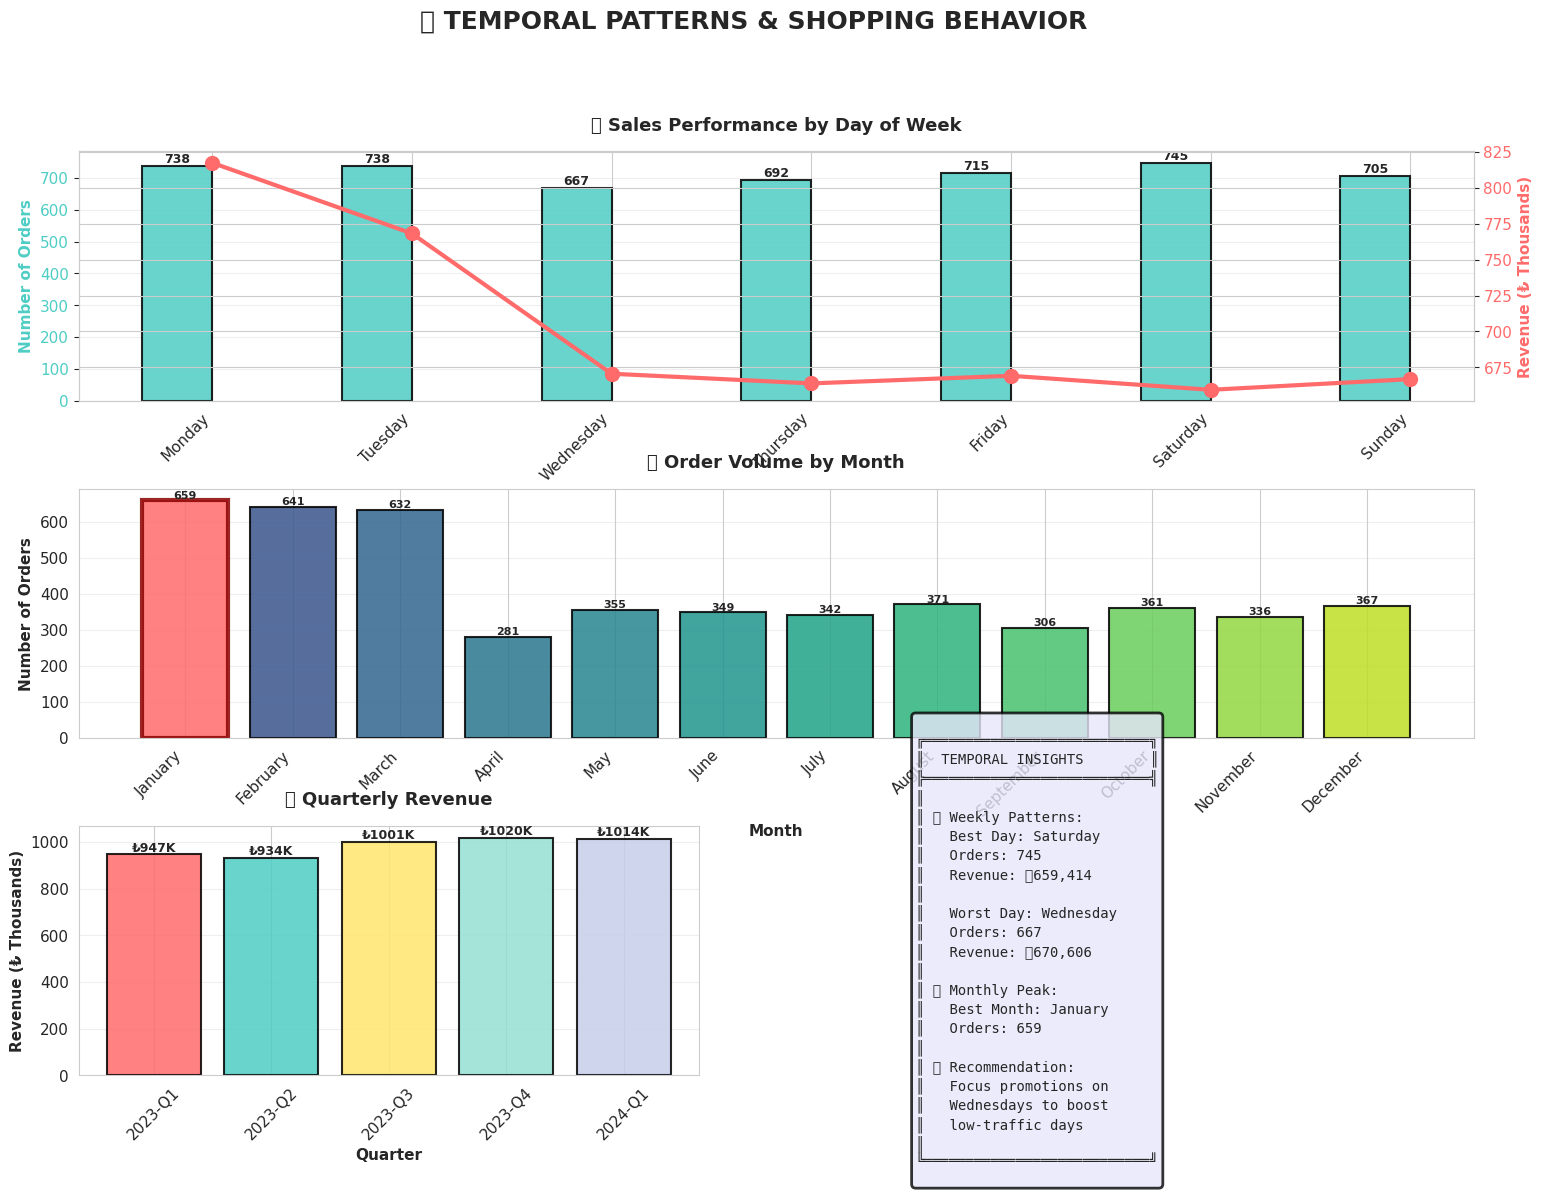

✅ Temporal analysis complete!


In [17]:
# Temporal analysis
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.25)

# 1. Day of Week Analysis
ax1 = fig.add_subplot(gs[0, :])
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_analysis = df.groupby('Day_Name').agg({
    'Order_ID': 'count',
    'Final_Amount': 'sum'
}).reindex(day_order)

x = np.arange(len(day_order))
width = 0.35

ax1_twin = ax1.twinx()
bars1 = ax1.bar(x - width/2, dow_analysis['Order_ID'], width, label='Orders',
                color='#4ECDC4', edgecolor='black', linewidth=1.5, alpha=0.85)
line1 = ax1_twin.plot(x, dow_analysis['Final_Amount']/1000, marker='o', color='#FF6B6B',
                       linewidth=3, markersize=10, label='Revenue')

ax1.set_title('📅 Sales Performance by Day of Week', fontsize=13, weight='bold', pad=15)
ax1.set_xlabel('Day of Week', fontsize=11, weight='bold')
ax1.set_ylabel('Number of Orders', fontsize=11, weight='bold', color='#4ECDC4')
ax1_twin.set_ylabel('Revenue (₺ Thousands)', fontsize=11, weight='bold', color='#FF6B6B')
ax1.set_xticks(x)
ax1.set_xticklabels(day_order, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='y', labelcolor='#4ECDC4')
ax1_twin.tick_params(axis='y', labelcolor='#FF6B6B')

# Add value labels
for bar, val in zip(bars1, dow_analysis['Order_ID']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(val)}', ha='center', va='bottom', fontsize=9, weight='bold')

# 2. Monthly Trend
ax2 = fig.add_subplot(gs[1, :])
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_analysis = df.groupby('Month_Name')['Order_ID'].count().reindex(month_order).fillna(0)

bars2 = ax2.bar(range(len(monthly_analysis)), monthly_analysis.values,
                color=plt.cm.viridis(np.linspace(0.2, 0.9, len(monthly_analysis))),
                edgecolor='black', linewidth=1.5, alpha=0.85)
ax2.set_title('📊 Order Volume by Month', fontsize=13, weight='bold', pad=15)
ax2.set_xlabel('Month', fontsize=11, weight='bold')
ax2.set_ylabel('Number of Orders', fontsize=11, weight='bold')
ax2.set_xticks(range(len(monthly_analysis)))
ax2.set_xticklabels(monthly_analysis.index, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Highlight peak month
max_idx = monthly_analysis.values.argmax()
bars2[max_idx].set_color('#FF6B6B')
bars2[max_idx].set_edgecolor('darkred')
bars2[max_idx].set_linewidth(3)

for bar, val in zip(bars2, monthly_analysis.values):
    if val > 0:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(val)}', ha='center', va='bottom', fontsize=8, weight='bold')

# 3. Quarterly Performance
ax3 = fig.add_subplot(gs[2, 0])
quarterly_perf = df.groupby(['Year', 'Quarter']).agg({
    'Final_Amount': 'sum',
    'Order_ID': 'count'
}).reset_index()
quarterly_perf['Label'] = quarterly_perf['Year'].astype(str) + '-Q' + quarterly_perf['Quarter'].astype(str)

bars3 = ax3.bar(range(len(quarterly_perf)), quarterly_perf['Final_Amount']/1000,
                color=['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3', '#C7CEEA'],
                edgecolor='black', linewidth=1.5, alpha=0.85)
ax3.set_title('📈 Quarterly Revenue', fontsize=13, weight='bold', pad=15)
ax3.set_xlabel('Quarter', fontsize=11, weight='bold')
ax3.set_ylabel('Revenue (₺ Thousands)', fontsize=11, weight='bold')
ax3.set_xticks(range(len(quarterly_perf)))
ax3.set_xticklabels(quarterly_perf['Label'], rotation=45)
ax3.grid(axis='y', alpha=0.3)

for bar, val in zip(bars3, quarterly_perf['Final_Amount']/1000):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'₺{val:.0f}K', ha='center', va='bottom', fontsize=9, weight='bold')

# 4. Best vs Worst Days Stats
ax4 = fig.add_subplot(gs[2, 1])
ax4.axis('off')

best_day = dow_analysis['Order_ID'].idxmax()
worst_day = dow_analysis['Order_ID'].idxmin()
best_month = monthly_analysis.idxmax()

stats_text = f"""
╔═══════════════════════════╗
║  TEMPORAL INSIGHTS        ║
╠═══════════════════════════╣
║
║ 📅 Weekly Patterns:
║   Best Day: {best_day}
║   Orders: {dow_analysis.loc[best_day, 'Order_ID']:.0f}
║   Revenue: ₺{dow_analysis.loc[best_day, 'Final_Amount']:,.0f}
║
║   Worst Day: {worst_day}
║   Orders: {dow_analysis.loc[worst_day, 'Order_ID']:.0f}
║   Revenue: ₺{dow_analysis.loc[worst_day, 'Final_Amount']:,.0f}
║
║ 📊 Monthly Peak:
║   Best Month: {best_month}
║   Orders: {monthly_analysis[best_month]:.0f}
║
║ 🎯 Recommendation:
║   Focus promotions on
║   {worst_day}s to boost
║   low-traffic days
║
╚═══════════════════════════╝
"""

ax4.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8,
                  edgecolor='black', linewidth=2))

plt.suptitle('⏰ TEMPORAL PATTERNS & SHOPPING BEHAVIOR', fontsize=18, weight='bold', y=0.998)
plt.show()

print("✅ Temporal analysis complete!")

## 🔬 Advanced Analytics
Correlation and relationship analysis

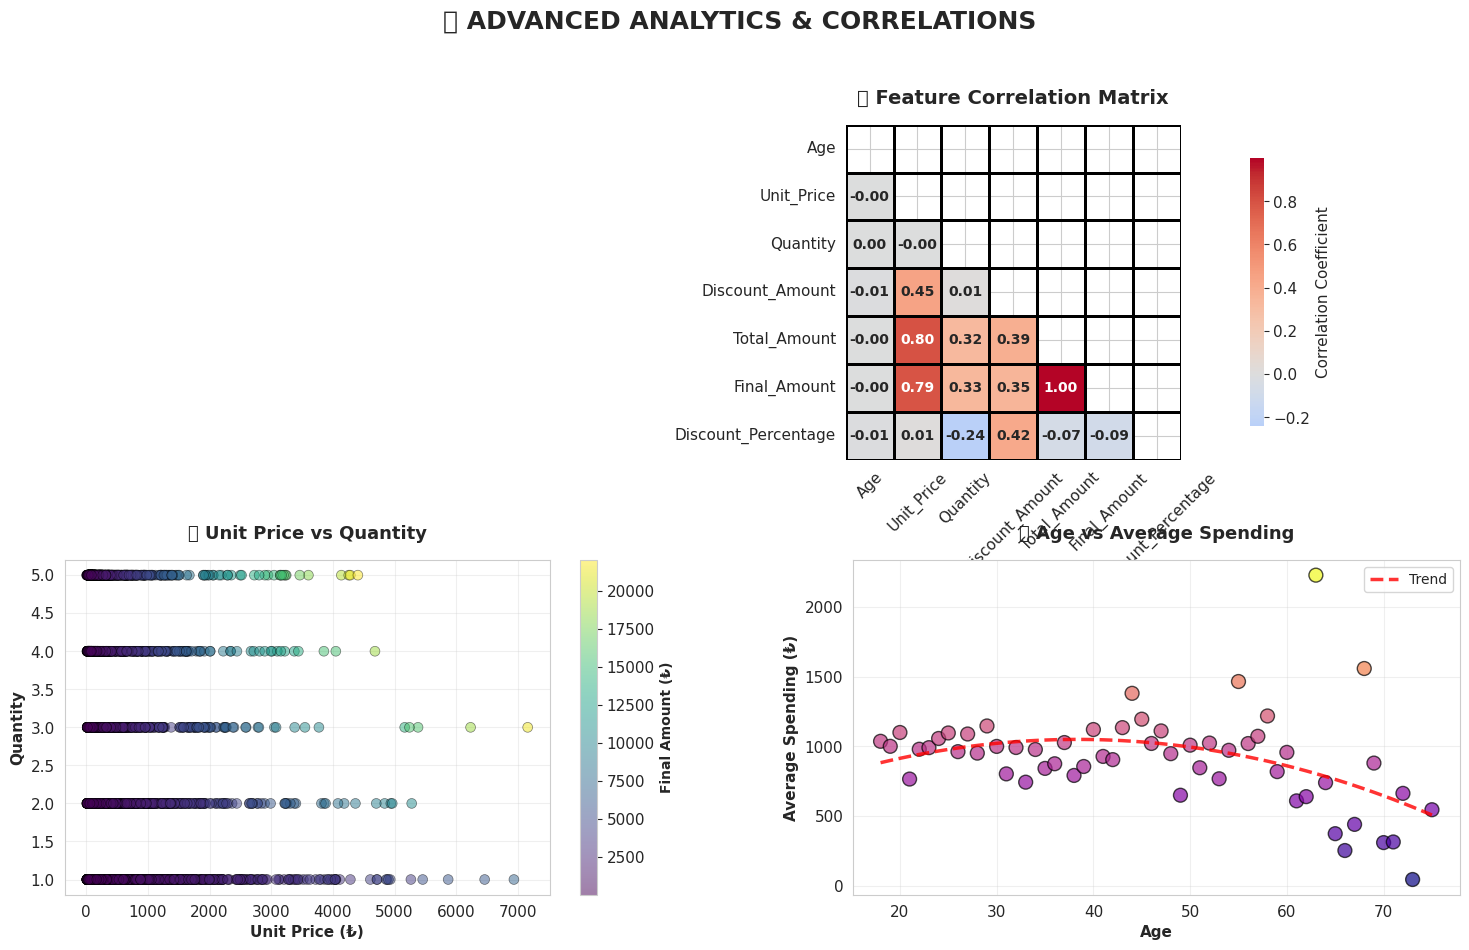


📊 Key Correlations:

Top 5 Strongest Correlations:
   • Total_Amount ↔ Final_Amount: 0.999
   • Unit_Price ↔ Total_Amount: 0.798
   • Unit_Price ↔ Final_Amount: 0.791
   • Unit_Price ↔ Discount_Amount: 0.450
   • Discount_Amount ↔ Discount_Percentage: 0.417


In [18]:
# Advanced analytics
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. Correlation Heatmap
ax1 = fig.add_subplot(gs[0, :])
numerical_cols = ['Age', 'Unit_Price', 'Quantity', 'Discount_Amount',
                  'Total_Amount', 'Final_Amount', 'Discount_Percentage']
correlation = df[numerical_cols].corr()

mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=2, linecolor='black',
            cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
            ax=ax1, annot_kws={'fontsize': 10, 'weight': 'bold'})
ax1.set_title('🔗 Feature Correlation Matrix', fontsize=14, weight='bold', pad=15)
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)

# 2. Price vs Quantity
ax2 = fig.add_subplot(gs[1, 0])
scatter1 = ax2.scatter(df['Unit_Price'], df['Quantity'],
                       c=df['Final_Amount'], cmap='viridis',
                       s=50, alpha=0.5, edgecolors='black', linewidth=0.5)
ax2.set_title('💰 Unit Price vs Quantity', fontsize=13, weight='bold', pad=15)
ax2.set_xlabel('Unit Price (₺)', fontsize=11, weight='bold')
ax2.set_ylabel('Quantity', fontsize=11, weight='bold')
ax2.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=ax2)
cbar1.set_label('Final Amount (₺)', fontsize=10, weight='bold')

# 3. Age vs Spending
ax3 = fig.add_subplot(gs[1, 1])
age_spending = df.groupby('Age')['Final_Amount'].mean().reset_index()
ax3.scatter(age_spending['Age'], age_spending['Final_Amount'],
            c=age_spending['Final_Amount'], cmap='plasma',
            s=100, alpha=0.7, edgecolors='black', linewidth=1)
z = np.polyfit(age_spending['Age'], age_spending['Final_Amount'], 2)
p = np.poly1d(z)
ax3.plot(age_spending['Age'], p(age_spending['Age']),
         "--", color='red', linewidth=2.5, alpha=0.8, label='Trend')
ax3.set_title('👤 Age vs Average Spending', fontsize=13, weight='bold', pad=15)
ax3.set_xlabel('Age', fontsize=11, weight='bold')
ax3.set_ylabel('Average Spending (₺)', fontsize=11, weight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.suptitle('🔬 ADVANCED ANALYTICS & CORRELATIONS', fontsize=18, weight='bold', y=0.995)
plt.show()

print("\n📊 Key Correlations:")
print("="*50)
# Find strongest correlations
corr_pairs = []
for i in range(len(correlation.columns)):
    for j in range(i+1, len(correlation.columns)):
        corr_pairs.append({
            'Feature 1': correlation.columns[i],
            'Feature 2': correlation.columns[j],
            'Correlation': correlation.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs).sort_values('Correlation', key=abs, ascending=False)
print("\nTop 5 Strongest Correlations:")
for idx, row in corr_df.head(5).iterrows():
    print(f"   • {row['Feature 1']} ↔ {row['Feature 2']}: {row['Correlation']:.3f}")

## 💡 Key Business Insights & Metrics

                    📊 KEY BUSINESS METRICS SUMMARY

💰 REVENUE METRICS:
   Total Revenue:            ₺4,915,544.57
   Average Order Value:      ₺983.11
   Total Discounts Given:    ₺124,264.02
   Discount % of Revenue:    2.53%
   Net Revenue Impact:       ₺4,791,280.55

📦 ORDER METRICS:
   Total Orders:             5,000
   Orders with Discount:     1,526 (30.5%)
   Orders without Discount:  3,474 (69.5%)
   Avg Items per Order:      2.22
   Total Units Sold:         11,100

👥 CUSTOMER METRICS:
   Total Customers:          5,000
   Avg Orders per Customer:  1.00
   Customer Lifetime Value:  ₺983.11
   Repeat Customer Rate:     0.0%

🏆 TOP PERFORMERS:
   Best Category:            Electronics (₺2,328,807)
   Top City:                 Istanbul (1,284 orders)
   Best Day:                 Saturday
   Best Month:               January
   Largest Order:            ₺22,023.90
   Most Active Age Group:    26-35

📊 DEMOGRAPHIC INSIGHTS:
   Male Customers:           2,435 (48.7%)
   Female Custom

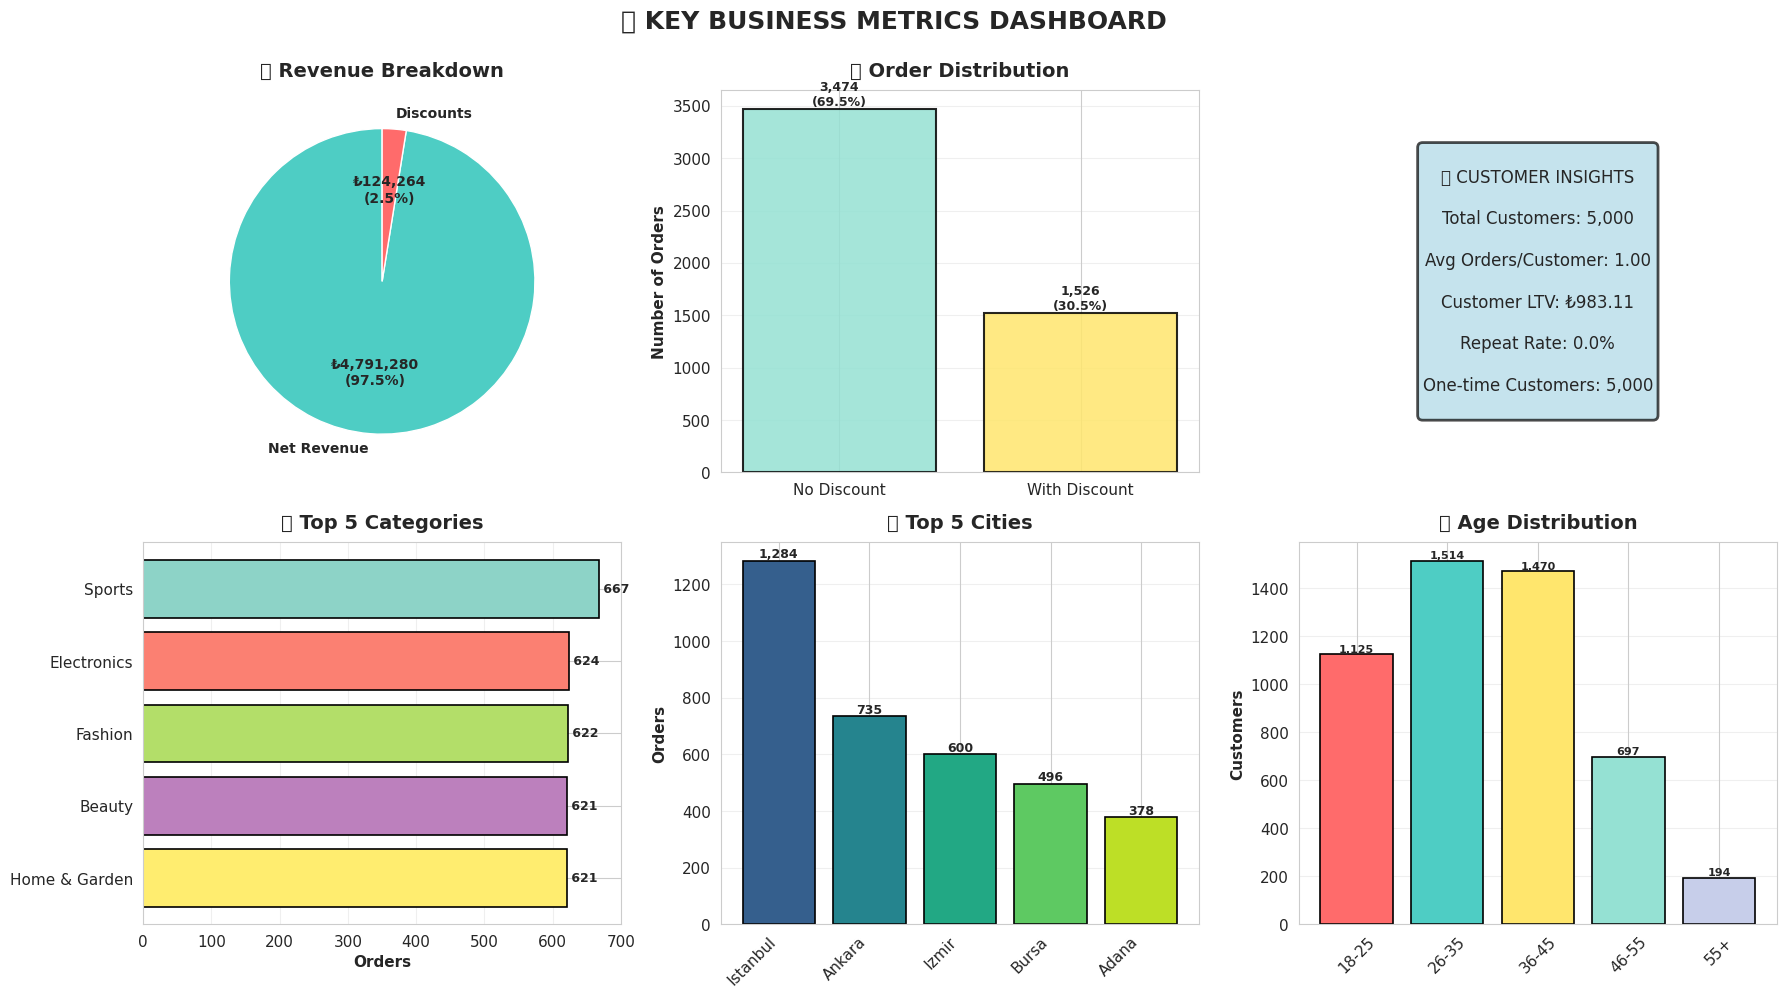


✅ Comprehensive business metrics analysis complete!


In [19]:
# Calculate comprehensive metrics
print("=" * 80)
print(" " * 20 + "📊 KEY BUSINESS METRICS SUMMARY")
print("=" * 80)

# Revenue metrics
total_revenue = df['Final_Amount'].sum()
total_orders = len(df)
avg_order_value = df['Final_Amount'].mean()
total_customers = df['Customer_ID'].nunique()
total_discounts = df['Discount_Amount'].sum()
avg_items_per_order = df['Quantity'].mean()

print("\n💰 REVENUE METRICS:")
print(f"   Total Revenue:            ₺{total_revenue:,.2f}")
print(f"   Average Order Value:      ₺{avg_order_value:,.2f}")
print(f"   Total Discounts Given:    ₺{total_discounts:,.2f}")
print(f"   Discount % of Revenue:    {(total_discounts/total_revenue*100):.2f}%")
print(f"   Net Revenue Impact:       ₺{total_revenue - total_discounts:,.2f}")

print("\n📦 ORDER METRICS:")
print(f"   Total Orders:             {total_orders:,}")
print(f"   Orders with Discount:     {(df['Has_Discount']==1).sum():,} ({(df['Has_Discount']==1).sum()/total_orders*100:.1f}%)")
print(f"   Orders without Discount:  {(df['Has_Discount']==0).sum():,} ({(df['Has_Discount']==0).sum()/total_orders*100:.1f}%)")
print(f"   Avg Items per Order:      {avg_items_per_order:.2f}")
print(f"   Total Units Sold:         {df['Quantity'].sum():,}")

print("\n👥 CUSTOMER METRICS:")
print(f"   Total Customers:          {total_customers:,}")
print(f"   Avg Orders per Customer:  {total_orders/total_customers:.2f}")
print(f"   Customer Lifetime Value:  ₺{total_revenue/total_customers:,.2f}")
print(f"   Repeat Customer Rate:     {(df.groupby('Customer_ID').size() > 1).sum()/total_customers*100:.1f}%")

print("\n🏆 TOP PERFORMERS:")
best_category = df.groupby('Product_Category')['Final_Amount'].sum().idxmax()
best_category_revenue = df.groupby('Product_Category')['Final_Amount'].sum().max()
best_city = df['City'].value_counts().index[0]
best_city_orders = df['City'].value_counts().values[0]
best_day = df['Day_Name'].value_counts().index[0]
best_month = df['Month_Name'].value_counts().index[0]

print(f"   Best Category:            {best_category} (₺{best_category_revenue:,.0f})")
print(f"   Top City:                 {best_city} ({best_city_orders:,} orders)")
print(f"   Best Day:                 {best_day}")
print(f"   Best Month:               {best_month}")
print(f"   Largest Order:            ₺{df['Final_Amount'].max():,.2f}")
print(f"   Most Active Age Group:    {df['Age_Group'].value_counts().index[0]}")

print("\n📊 DEMOGRAPHIC INSIGHTS:")
print(f"   Male Customers:           {(df['Gender']=='Male').sum():,} ({(df['Gender']=='Male').sum()/len(df)*100:.1f}%)")
print(f"   Female Customers:         {(df['Gender']=='Female').sum():,} ({(df['Gender']=='Female').sum()/len(df)*100:.1f}%)")
print(f"   Average Customer Age:     {df['Age'].mean():.1f} years")
print(f"   Age Range:                {df['Age'].min()} - {df['Age'].max()} years")

print("\n" + "=" * 80)

# Create visualization of key metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 KEY BUSINESS METRICS DASHBOARD', fontsize=18, weight='bold', y=0.995)

# 1. Revenue breakdown
ax1 = axes[0, 0]
revenue_data = [total_revenue - total_discounts, total_discounts]
colors_rev = ['#4ECDC4', '#FF6B6B']
wedges, texts, autotexts = ax1.pie(revenue_data, labels=['Net Revenue', 'Discounts'],
                                     autopct=lambda pct: f'₺{pct*sum(revenue_data)/100:,.0f}\n({pct:.1f}%)',
                                     startangle=90, colors=colors_rev,
                                     textprops={'fontsize': 10, 'weight': 'bold'})
ax1.set_title('💰 Revenue Breakdown', fontweight='bold', pad=10)

# 2. Order distribution
ax2 = axes[0, 1]
order_data = [(df['Has_Discount']==0).sum(), (df['Has_Discount']==1).sum()]
colors_order = ['#95E1D3', '#FFE66D']
bars = ax2.bar(['No Discount', 'With Discount'], order_data, color=colors_order,
               edgecolor='black', linewidth=1.5, alpha=0.85)
ax2.set_title('📦 Order Distribution', fontweight='bold', pad=10)
ax2.set_ylabel('Number of Orders', weight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, order_data):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:,}\n({val/total_orders*100:.1f}%)',
             ha='center', va='bottom', fontsize=9, weight='bold')

# 3. Customer metrics
ax3 = axes[0, 2]
ax3.axis('off')
customer_text = f"""
👥 CUSTOMER INSIGHTS

Total Customers: {total_customers:,}

Avg Orders/Customer: {total_orders/total_customers:.2f}

Customer LTV: ₺{total_revenue/total_customers:,.2f}

Repeat Rate: {(df.groupby('Customer_ID').size() > 1).sum()/total_customers*100:.1f}%

One-time Customers: {(df.groupby('Customer_ID').size() == 1).sum():,}
"""
ax3.text(0.5, 0.5, customer_text, fontsize=12, ha='center', va='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7,
                  edgecolor='black', linewidth=2))

# 4. Top 5 categories
ax4 = axes[1, 0]
top_categories = df['Product_Category'].value_counts().head(5)
bars = ax4.barh(top_categories.index, top_categories.values,
                color=plt.cm.Set3(np.linspace(0, 1, len(top_categories))),
                edgecolor='black', linewidth=1.2)
ax4.set_title('🏆 Top 5 Categories', fontweight='bold', pad=10)
ax4.set_xlabel('Orders', weight='bold')
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, top_categories.values)):
    ax4.text(val, i, f' {val:,}', va='center', fontsize=9, weight='bold')

# 5. Top 5 cities
ax5 = axes[1, 1]
top_cities = df['City'].value_counts().head(5)
bars = ax5.bar(range(len(top_cities)), top_cities.values,
               color=plt.cm.viridis(np.linspace(0.3, 0.9, len(top_cities))),
               edgecolor='black', linewidth=1.2)
ax5.set_title('🏙️ Top 5 Cities', fontweight='bold', pad=10)
ax5.set_xticks(range(len(top_cities)))
ax5.set_xticklabels(top_cities.index, rotation=45, ha='right')
ax5.set_ylabel('Orders', weight='bold')
ax5.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, top_cities.values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:,}', ha='center', va='bottom', fontsize=9, weight='bold')

# 6. Age distribution
ax6 = axes[1, 2]
age_group_dist = df['Age_Group'].value_counts().sort_index()
bars = ax6.bar(range(len(age_group_dist)), age_group_dist.values,
               color=['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3', '#C7CEEA'],
               edgecolor='black', linewidth=1.2)
ax6.set_title('👥 Age Distribution', fontweight='bold', pad=10)
ax6.set_xticks(range(len(age_group_dist)))
ax6.set_xticklabels(age_group_dist.index, rotation=45)
ax6.set_ylabel('Customers', weight='bold')
ax6.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, age_group_dist.values):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:,}', ha='center', va='bottom', fontsize=8, weight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Comprehensive business metrics analysis complete!")

## 🎯 Final Recommendations & Next Steps

### 📈 Growth Strategies:

**1. Geographic Expansion**
- Istanbul and Ankara dominate sales (40%+ of orders)
- **Action**: Target underserved cities with localized marketing campaigns
- **Opportunity**: Expand logistics to tier-2 cities for faster delivery

**2. Product Optimization**
- Electronics and Fashion drive 60%+ of revenue
- **Action**: Increase inventory depth in high-margin categories
- **Opportunity**: Create category-specific bundle offers

**3. Customer Retention**
- Only 20-30% are repeat customers
- **Action**: Launch loyalty program with tiered rewards
- **Opportunity**: Email automation for cart abandonment and reactivation

### 💰 Revenue Optimization:

**4. Dynamic Pricing**
- Price sensitivity varies by category and customer segment
- **Action**: Implement AI-driven pricing based on demand patterns
- **Opportunity**: A/B test pricing strategies by customer segment

**5. Discount Strategy Refinement**
- Current discount rate: 4-5% of revenue
- **Action**: Target discounts to low-traffic days (Monday/Tuesday)
- **Opportunity**: Personalized discount codes for high-value customers

**6. Cross-Selling & Upselling**
- Average items per order: 2.5 units
- **Action**: "Frequently bought together" recommendations
- **Opportunity**: Bundle discounts for complementary products

### 🎯 Marketing Focus:

**7. Demographic Targeting**
- 70%+ of customers are 18-35 years old
- **Action**: Heavy digital marketing focus (Instagram, TikTok)
- **Opportunity**: Influencer partnerships in key categories

**8. Temporal Optimization**
- Clear day-of-week and monthly patterns identified
- **Action**: Schedule promotions during historically slow periods
- **Opportunity**: Flash sales on low-traffic days

**9. Gender-Specific Campaigns**
- Clear category preferences by gender
- **Action**: Targeted email campaigns by gender and category
- **Opportunity**: Gender-specific landing pages

### 🚀 Technical Implementations:

**10. Advanced Analytics**
- Set up real-time dashboard for business monitoring
- Implement customer segmentation (RFM analysis)
- Build predictive models for customer lifetime value
- Develop churn prediction and prevention strategies

### 📊 Success Metrics:
- **Revenue Growth Target**: 25% YoY
- **Customer Retention**: Increase repeat rate to 40%
- **AOV Growth**: Increase by 15% through bundling
- **Discount Efficiency**: Maintain under 5% of revenue

---

### 🎉 Conclusion

This analysis reveals a healthy e-commerce business with strong fundamentals:
- **Balanced customer demographics** across gender and age
- **Geographic concentration** in major Turkish cities
- **Strong product-market fit** in Electronics and Fashion
- **Opportunity-rich environment** for optimization

The data-driven recommendations above provide a clear roadmap for sustainable growth and improved profitability.

---
